# ML Experiment Results Analysis & Visualization
## Invoice Payment Prediction — April 2026 Corrected Re-run

**Source DB:** `results/2026_04_25_01/results.db`  
**Experiments:** 1092 total (15 models × 7 balance strategies × ~10 param sets × 2 feature phases)  
**Primary metrics:** `enhanced_f1_macro`, `enhanced_roc_auc_macro`  
**Output figures:** `data/results_graphics/RG_2026_04_18_02/`

---
All four pipeline bugs (resample accumulation, Cox leakage, pickling, nested parallelism) were fixed before this run. Schema v3 — `undersample_threshold` fully populated for all hybrid rows.

In [1]:
from pathlib import Path
import sys
import os

# Automatically find repo root by looking for .git
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.chdir(ROOT)

print(f"Current root: {ROOT}")

Current root: c:\Users\rjbel\Python\Notebooks\Mapua\Thesis


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ── New analysis module ───────────────────────────────────────────────────────
from src.modules.machine_learning.utils.io.analysis import (
    ResultsAnalyzer,
    ALL_MODELS,
    BASE_MODELS,
    ORDINAL_MODELS,
    TWO_STAGE_MODELS,
    MODEL_DISPLAY,
    FAMILY_MAP,
    FAMILY_PALETTE,
    STRATEGY_ORDER,
    STRATEGY_LABELS,
    CLASS_NAMES,
    ORDINAL_BASE_MAP,
    TWO_STAGE_BASE_MAP,
    SURVIVAL_FEATURES,
    Theme,
)

warnings.filterwarnings("ignore")

# ── Create analyzer (replaces manual SessionStore + repo wiring) ──────────────
ra = ResultsAnalyzer("data/training_results/")

session_name = ra.current_session
DB_PATH      = ra.repo.db_path          # escape hatch: raw DB path for SQLite queries
                                         # (sections 8, 9 use it directly)

# Derive output folder name from session directory (format: YYYY_MM_DD_VV)
parts = session_name.split("_")
if len(parts) >= 4:
    date_str, version_str = f"{parts[0]}_{parts[1]}_{parts[2]}", parts[3]
    output_folder_name = f"RG_{date_str}_{version_str}"
else:
    output_folder_name = f"RG_{session_name}"

OUTPUT_DIR = Path("data/results_graphics") / output_folder_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Apply notebook theme (replaces the inline rcParams block) ─────────────────
Theme.apply("notebook")

# ── Strategy palette (still built here; not yet in registry) ─────────────────
STRATEGY_PALETTE = dict(zip(STRATEGY_ORDER, sns.color_palette("tab10", 7)))

print("✓ Configuration loaded")
print(f"  Session  : {session_name}")
print(f"  DB       : {DB_PATH}")
print(f"  Output   : {OUTPUT_DIR.resolve()}")

✓ Configuration loaded
  Session  : 2026_05_09_02
  DB       : data/training_results/2026_05_09_02\results.db
  Output   : C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\data\results_graphics\RG_2026_05_09_02


## Section 1 — Load Results Database

In [3]:
# ── Load via ResultsAnalyzer ──────────────────────────────────────────────────
#
# ra.df         → full experiments + metrics DataFrame (derived cols already added)
# ra.metadata   → session metadata dict
# ra.survival   → CoxPH survival results dict
# ra.class_mappings → class label → int encoding
#
# The analyzer lazily builds ra.df from the DB on first access, handling the
# pivot, column renaming, and derived-column computation that was previously
# done inline.

df            = ra.df                       # full DataFrame (copy)
class_mappings = ra.class_mappings
survival_data  = ra.survival
metadata       = ra.metadata

print(f"✓  Loaded {len(df):,} experiments")
print(f"   Metric columns: {[c for c in df.columns if 'f1' in c or 'auc' in c]}")
print(f"\n   Metadata :")
print(f"     Run start  : {metadata.get('training_start_time', '?')}")
print(f"     Run end    : {metadata.get('training_end_time', '?')}")
print(f"     Duration   : {metadata.get('training_run_time', '?')}")
print(f"\n   CoxPH survival results :")
print(f"     C-index    : {survival_data.get('best_c_index', '?')}")
print(f"     Best params: {survival_data.get('best_parameters', '?')}")

✓  Loaded 1,092 experiments
   Metric columns: ['baseline_f1_macro', 'baseline_roc_auc_macro', 'enhanced_f1_macro', 'enhanced_roc_auc_macro', 'f1_lift']

   Metadata :
     Run start  : 2026-05-09T19:54:34
     Run end    : 2026-05-09T21:57:42
     Duration   : 2h 3m 7s

   CoxPH survival results :
     C-index    : 0.7817
     Best params: {'alpha': 0.05, 'l1_ratio': 0.5}


## Section 2 — Data Quality Check

In [4]:
# ── Run structured quality checks via the analysis module ─────────────────────
qr = ra.quality()
print(qr)

# Unpack for downstream compatibility (sections that reference these variables directly)
strat_counts = qr.strategy_counts
model_counts = qr.model_counts

QualityReport: ✓ PASSED
  Mean F1 lift: -0.0010
  Negative lifts (< −0.02): 36


## Section 3 — Model Rankings by Primary Metrics

In [5]:
DISPLAY_COLS = {
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Balance Strategy",
    "enhanced_f1_macro":      "F1 (enhanced)",
    "enhanced_roc_auc_macro": "AUC (enhanced)",
    "baseline_f1_macro":      "F1 (baseline)",
    "baseline_roc_auc_macro": "AUC (baseline)",
    "param_hash":             "Params",
}

# ── Top-20 by enhanced F1 ─────────────────────────────────────────────────────
rank_f1 = (
    ra.top(20, by="enhanced_f1_macro")
      .df
      .reset_index(drop=True)
)
rank_f1.index += 1
print("=== Top-20 by enhanced_f1_macro ===")
print(rank_f1[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Top-20 by enhanced AUC ────────────────────────────────────────────────────
rank_auc = (
    ra.top(20, by="enhanced_roc_auc_macro")
      .df
      .reset_index(drop=True)
)
rank_auc.index += 1
print("\n=== Top-20 by enhanced_roc_auc_macro ===")
print(rank_auc[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Rank correlation ──────────────────────────────────────────────────────────
corr_result = ra.rank_correlation("enhanced_f1_macro", "enhanced_roc_auc_macro")
rho_num = corr_result.statistic
pval    = corr_result.p_value
direction = "strongly" if abs(rho_num) > 0.8 else "moderately"
print(f"\nSpearman ρ(F1, AUC) = {rho_num:.4f}  p = {pval:.2e}")
print(f"→ F1 and AUC are {direction} correlated — rankings are consistent.")

=== Top-20 by enhanced_f1_macro ===
         Model     Family  Balance Strategy  F1 (enhanced)  AUC (enhanced)  F1 (baseline)  AUC (baseline)  Params
1   TS XGB→Ada  Two-Stage  borderline_smote       0.600278        0.881909       0.592991        0.876275  3897d4
2   TS XGB→Ada  Two-Stage  borderline_smote       0.597576        0.879968       0.595785        0.880233  fa3bba
3   TS XGB→Ada  Two-Stage  borderline_smote       0.594753        0.880110       0.594314        0.879044  f384e0
4   TS XGB→Ada  Two-Stage  borderline_smote       0.594597        0.878754       0.595985        0.878008  69c4d1
5   TS XGB→Ada  Two-Stage  borderline_smote       0.594515        0.883542       0.598297        0.881539  8c29d5
6   TS XGB→Ada  Two-Stage  borderline_smote       0.593653        0.877080       0.594207        0.877051  39d40b
7    TS RF→Ada  Two-Stage  borderline_smote       0.588012        0.871617       0.592380        0.875625  838817
8    TS RF→Ada  Two-Stage  borderline_smote       0.

## Section 4 — Best Model per Family Analysis

In [6]:
best_per_model = (
    ra.best_per("model", by="enhanced_f1_macro")
      .df
      .sort_values("enhanced_f1_macro", ascending=False)
      .reset_index(drop=True)
)
best_per_model.index += 1

summary_cols = ["model_display", "family", "strategy_label",
                "enhanced_f1_macro", "enhanced_roc_auc_macro",
                "baseline_f1_macro", "f1_lift"]
summary_cols = [c for c in summary_cols if c in best_per_model.columns]

print("=== Best configuration per model type (ranked by enhanced_f1_macro) ===\n")
print(best_per_model[summary_cols].rename(columns={
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Best Strategy",
    "enhanced_f1_macro":      "F1 (enh.)",
    "enhanced_roc_auc_macro": "AUC (enh.)",
    "baseline_f1_macro":      "F1 (base.)",
    "f1_lift":                "Lift",
}).to_string())

# ── Best per family ───────────────────────────────────────────────────────────
print("\n=== Best per family ===")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub = best_per_model[best_per_model["family"] == fam]
    if sub.empty:
        continue
    top = sub.iloc[0]
    print(f"\n  {fam:12s}  →  {top['model_display']}")
    print(f"             Strategy : {top['strategy_label']}")
    print(f"             F1 (enh) : {top['enhanced_f1_macro']:.4f}")
    print(f"             AUC(enh) : {top['enhanced_roc_auc_macro']:.4f}")

print("\n✓ best_per_model stored for downstream sections")

=== Best configuration per model type (ranked by enhanced_f1_macro) ===

               Model     Family     Best Strategy  F1 (enh.)  AUC (enh.)  F1 (base.)      Lift
1         TS XGB→Ada  Two-Stage  borderline_smote   0.600278    0.881909    0.592991  0.007287
2          TS RF→Ada  Two-Stage  borderline_smote   0.588012    0.871617    0.592380 -0.004369
3           TS RF→RF  Two-Stage             smote   0.564603    0.865986    0.559635  0.004968
4   Ordinal AdaBoost    Ordinal        hybrid@0.5   0.562098    0.820452    0.564224 -0.002126
5          TS XGB→RF  Two-Stage             smote   0.560571    0.866873    0.546195  0.014376
6            XGBoost       Base        hybrid@0.5   0.558924    0.860746    0.556489  0.002434
7           AdaBoost       Base             smote   0.558157    0.813735    0.558157  0.000000
8      Random Forest       Base        hybrid@0.5   0.558097    0.856626    0.548978  0.009119
9         TS XGB→XGB  Two-Stage             smote   0.552069    0.869962

## Section 5 — Ordinal & Two-Stage vs Base Classifier Comparison

=== Ordinal & Two-Stage lift over base classifiers (best config) ===

--- F1 macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.5582   0.6003  0.0421
       TS RF→Ada      AdaBoost Two-Stage 0.5582   0.5880  0.0299
        TS RF→RF Random Forest Two-Stage 0.5581   0.5646  0.0065
Ordinal AdaBoost      AdaBoost   Ordinal 0.5582   0.5621  0.0039
       TS XGB→RF Random Forest Two-Stage 0.5581   0.5606  0.0025
      TS XGB→XGB       XGBoost Two-Stage 0.5589   0.5521 -0.0069
      Ordinal RF Random Forest   Ordinal 0.5581   0.5498 -0.0083
      TS Ada→XGB       XGBoost Two-Stage 0.5589   0.5459 -0.0130
 Ordinal XGBoost       XGBoost   Ordinal 0.5589   0.5450 -0.0139

--- AUC macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.8517   0.8835  0.0319
       TS RF→Ada      AdaBoost Two-Stage 0.8517   0.8732  0.0215
       TS XGB→RF Random Forest Two-Stage 0.8627  

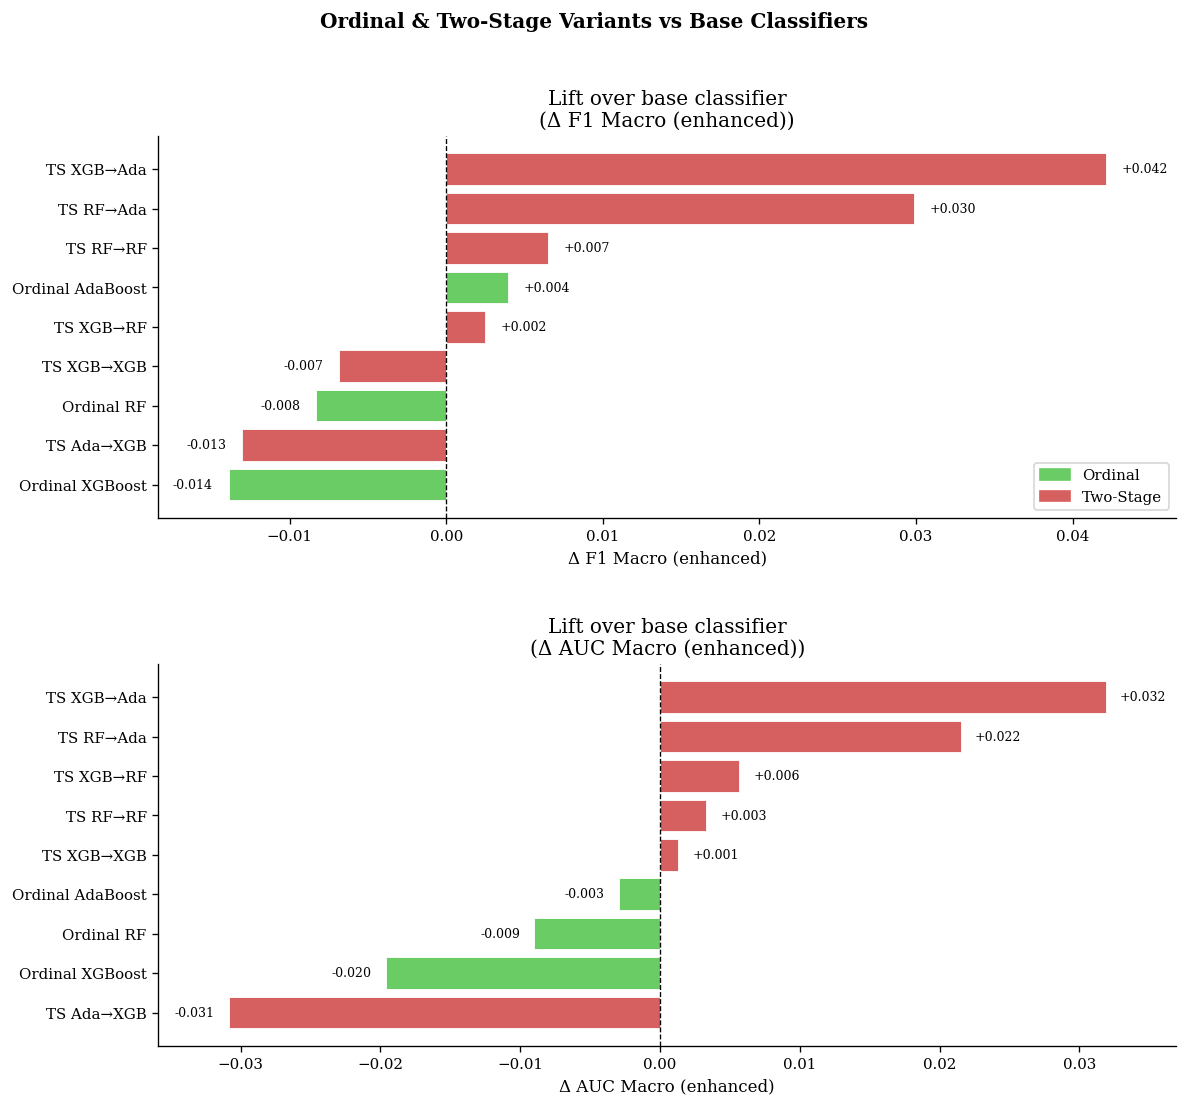

✓ Saved fig_ordinal_twostage_lift.png


In [7]:
# ── variant_lift via ResultsAnalyzer ─────────────────────────────────────────
cmp_df = ra.variant_lift()

print("=== Ordinal & Two-Stage lift over base classifiers (best config) ===\n")
for metric_short in ("f1", "roc_auc"):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=False)
    label = "F1 macro" if metric_short == "f1" else "AUC macro"
    print(f"--- {label} ---")
    print(sub[["variant", "base", "type", "base_val", "variant_val", "delta"]]
          .rename(columns={"base_val": "Base", "variant_val": "Variant", "delta": "Δ"})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()

# ── Bar chart: delta F1 by variant type ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 9))
for ax, metric_short, ylabel in zip(
    axes,
    ["f1", "roc_auc"],
    ["Δ F1 Macro (enhanced)", "Δ AUC Macro (enhanced)"]
):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=True)
    colors = [FAMILY_PALETTE["Ordinal"] if t == "Ordinal"
              else FAMILY_PALETTE["Two-Stage"]
              for t in sub["type"]]
    bars = ax.barh(sub["variant"], sub["delta"], color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(ylabel)
    ax.set_title(f"Lift over base classifier\n({ylabel})")
    for bar, val in zip(bars, sub["delta"]):
        x = bar.get_width()
        if x >= 0:
            ax.text(x + 0.001, bar.get_y() + bar.get_height() / 2,
                    f"{val:+.3f}", va="center", ha="left", fontsize=7.5)
        else:
            ax.text(x - 0.001, bar.get_y() + bar.get_height() / 2,
                    f"{val:+.3f}", va="center", ha="right", fontsize=7.5)
    ax.margins(x=0.08)

legend_patches = [
    mpatches.Patch(color=FAMILY_PALETTE["Ordinal"],   label="Ordinal"),
    mpatches.Patch(color=FAMILY_PALETTE["Two-Stage"], label="Two-Stage"),
]
axes[0].legend(handles=legend_patches, loc="lower right")
plt.suptitle("Ordinal & Two-Stage Variants vs Base Classifiers", fontweight="bold", y=1.02)
plt.tight_layout(h_pad=3)
plt.savefig(OUTPUT_DIR / "fig_ordinal_twostage_lift.png", bbox_inches="tight")
plt.show()
print("✓ Saved fig_ordinal_twostage_lift.png")

## Section 6 — F1 and AUC Bar Charts per Balance Strategy

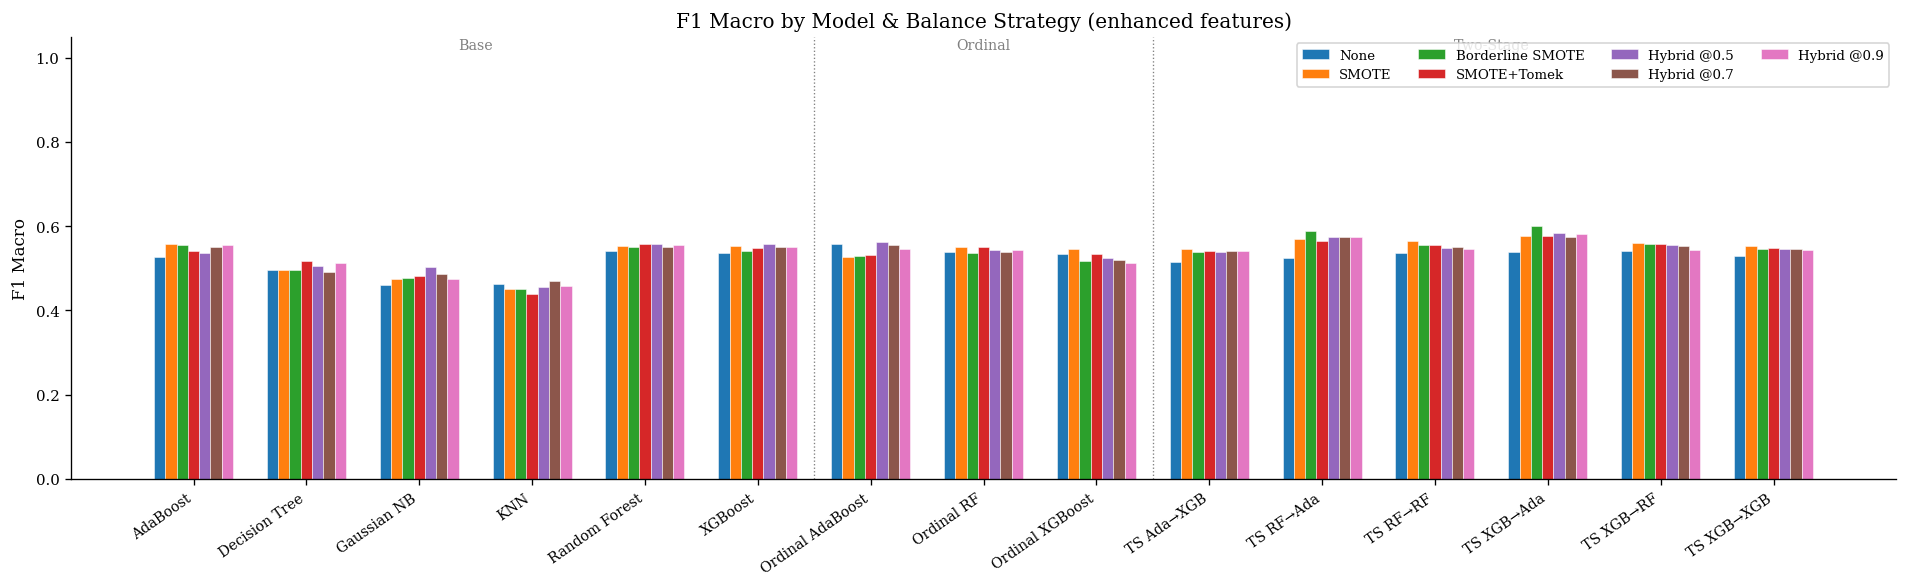

✓ Saved fig_f1_by_strategy.png


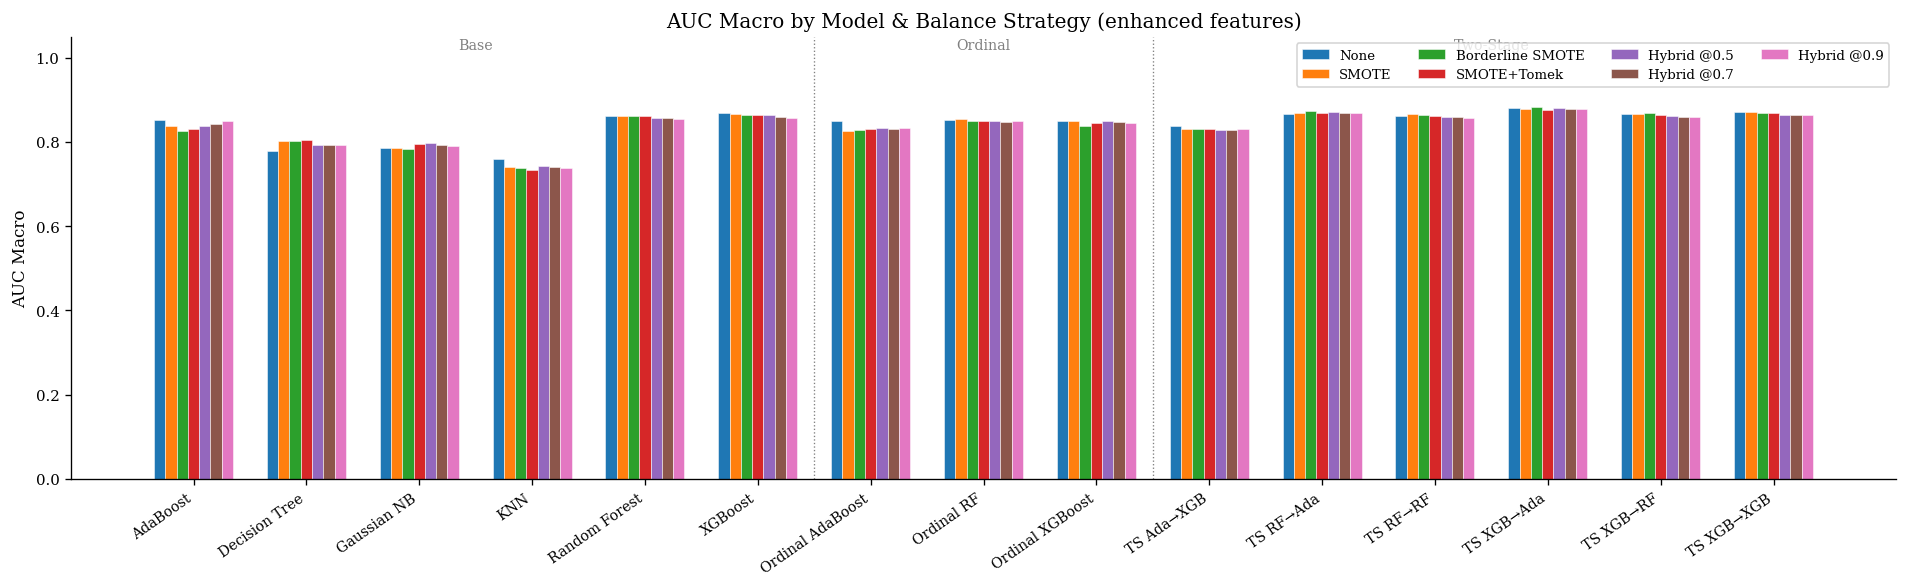

✓ Saved fig_auc_by_strategy.png


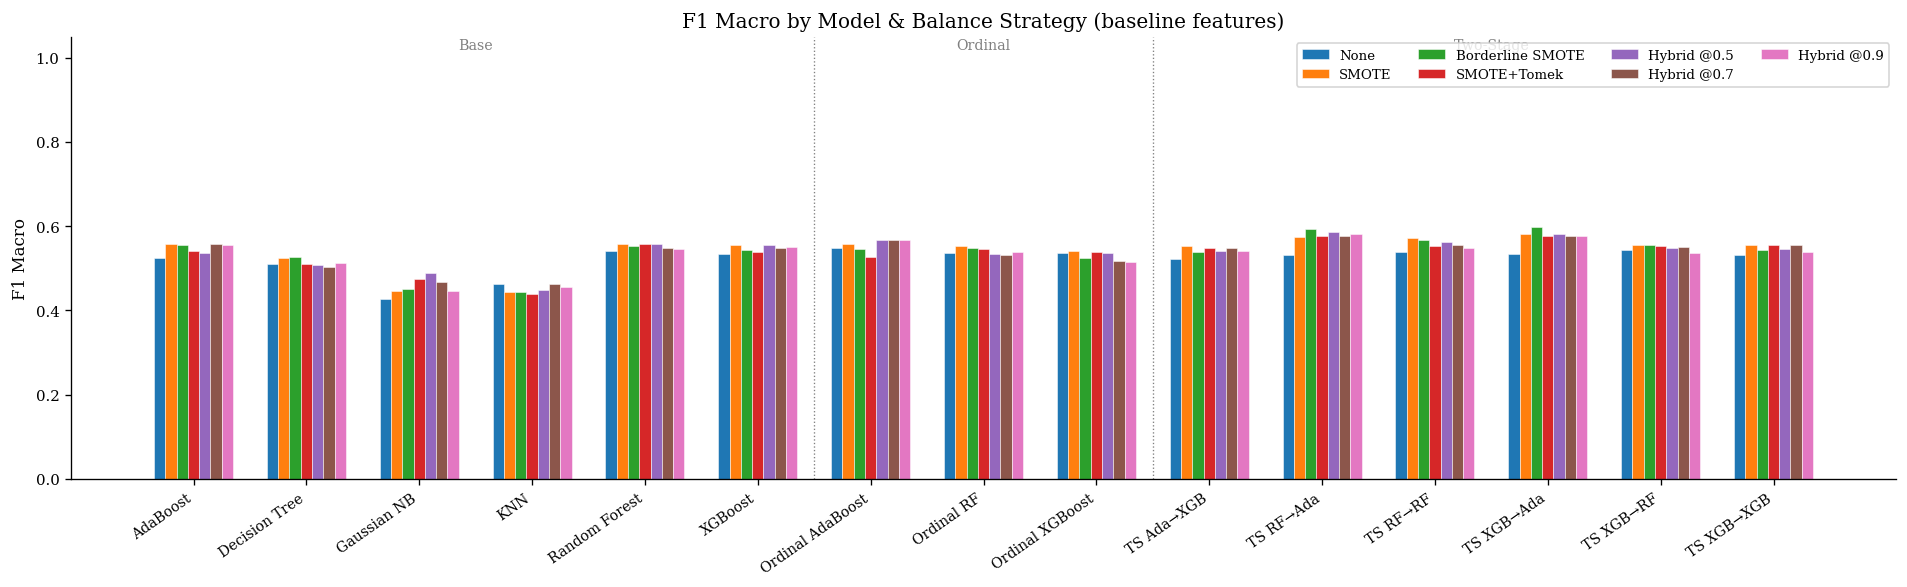

✓ Saved fig_f1_baseline_by_strategy.png


In [8]:
# For each model type: best F1 per strategy (max across param sets)
agg = (
    df.groupby(["model", "strategy_label"])[
        ["enhanced_f1_macro", "enhanced_roc_auc_macro",
         "baseline_f1_macro", "baseline_roc_auc_macro"]
    ]
    .max()
    .reset_index()
)


def _plot_metric_bar(metric_col, ylabel, title_suffix, fname):
    """Grouped bar chart: model × strategy, for one metric."""
    n_models     = len(ALL_MODELS)
    n_strategies = len(STRATEGY_ORDER)
    x       = np.arange(n_models)
    width   = 0.10
    offsets = np.linspace(-(n_strategies - 1) / 2 * width,
                           (n_strategies - 1) / 2 * width,
                           n_strategies)

    fig, ax = plt.subplots(figsize=(16, 5))
    for i, strat in enumerate(STRATEGY_ORDER):
        vals = []
        for m in ALL_MODELS:
            row = agg[(agg["model"] == m) & (agg["strategy_label"] == strat)]
            vals.append(row[metric_col].values[0] if len(row) else np.nan)
        color = STRATEGY_PALETTE[strat]
        ax.bar(x + offsets[i], vals, width, label=STRATEGY_LABELS[strat],
               color=color, edgecolor="white", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY.get(str(m), str(m)) for m in ALL_MODELS],
                       rotation=35, ha="right", fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Model & Balance Strategy ({title_suffix})")
    ax.legend(ncol=4, fontsize=8, loc="upper right")
    ax.set_ylim(0, 1.05)

    # Family separators
    base_end = len(BASE_MODELS) - 0.5
    ord_end  = base_end + len(ORDINAL_MODELS)
    for xpos in [base_end, ord_end]:
        ax.axvline(xpos, color="gray", linewidth=0.8, linestyle=":")
    ax.text(len(BASE_MODELS) / 2 - 0.5, 1.02, "Base",
            ha="center", fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS) / 2 - 0.5, 1.02, "Ordinal",
            ha="center", fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS) + len(TWO_STAGE_MODELS) / 2 - 0.5, 1.02,
            "Two-Stage", ha="center", fontsize=8.5, color="gray")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname)
    plt.show()
    print(f"✓ Saved {fname}")


_plot_metric_bar("enhanced_f1_macro",      "F1 Macro",  "enhanced features", "fig_f1_by_strategy.png")
_plot_metric_bar("enhanced_roc_auc_macro", "AUC Macro", "enhanced features", "fig_auc_by_strategy.png")
_plot_metric_bar("baseline_f1_macro",      "F1 Macro",  "baseline features", "fig_f1_baseline_by_strategy.png")

## Section 7 — Heatmap: Model × Balance Strategy × Feature Selection

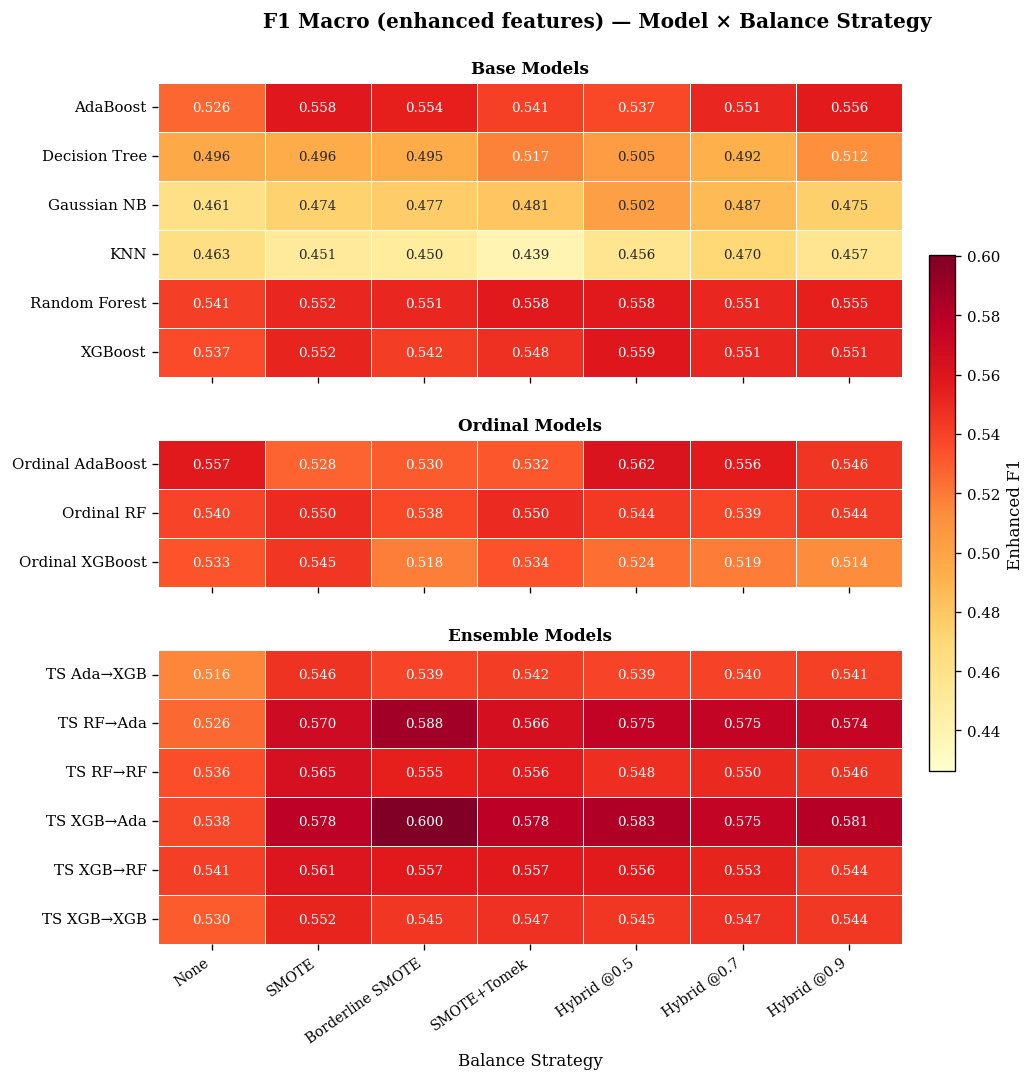

✓ Saved fig_heatmap_f1_enhanced.png


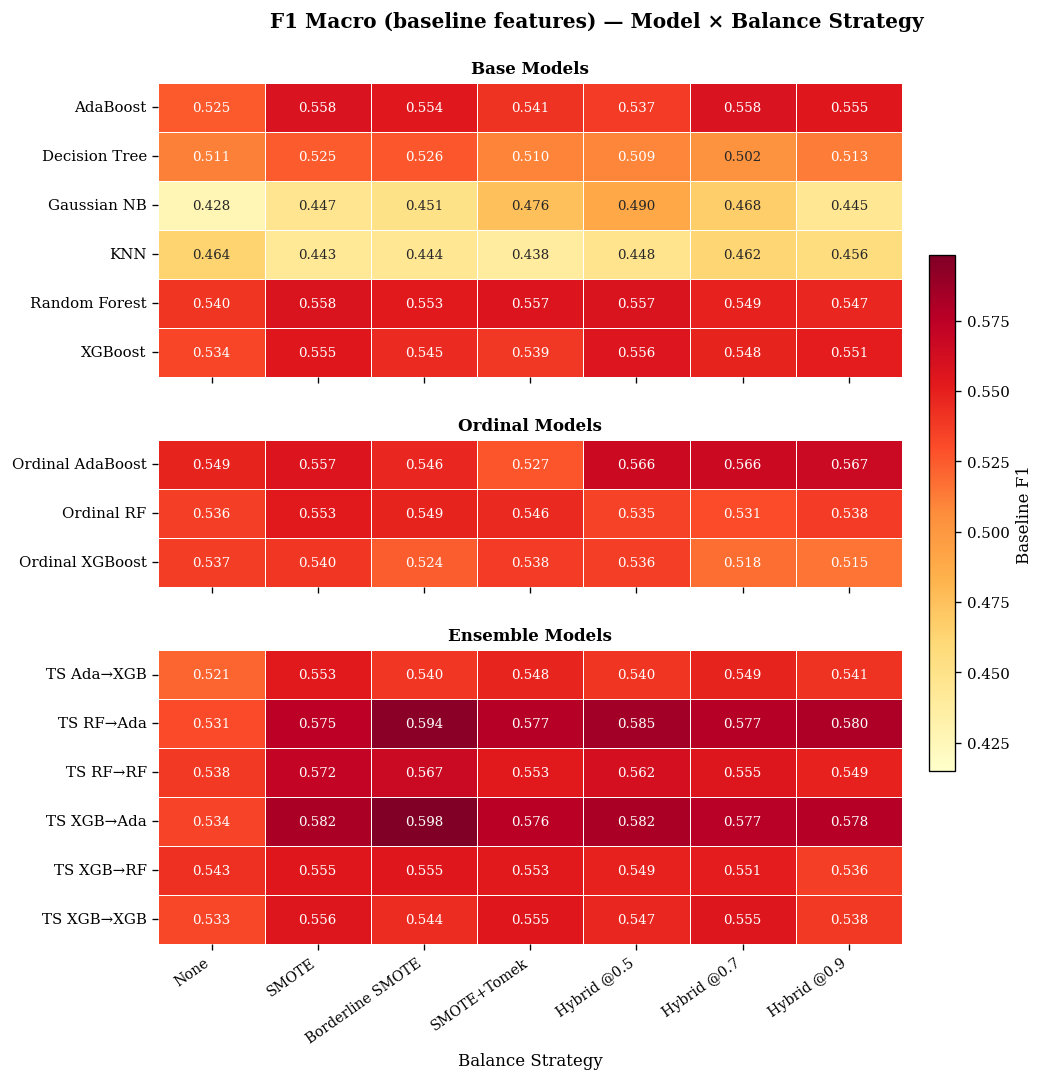

✓ Saved fig_heatmap_f1_baseline.png


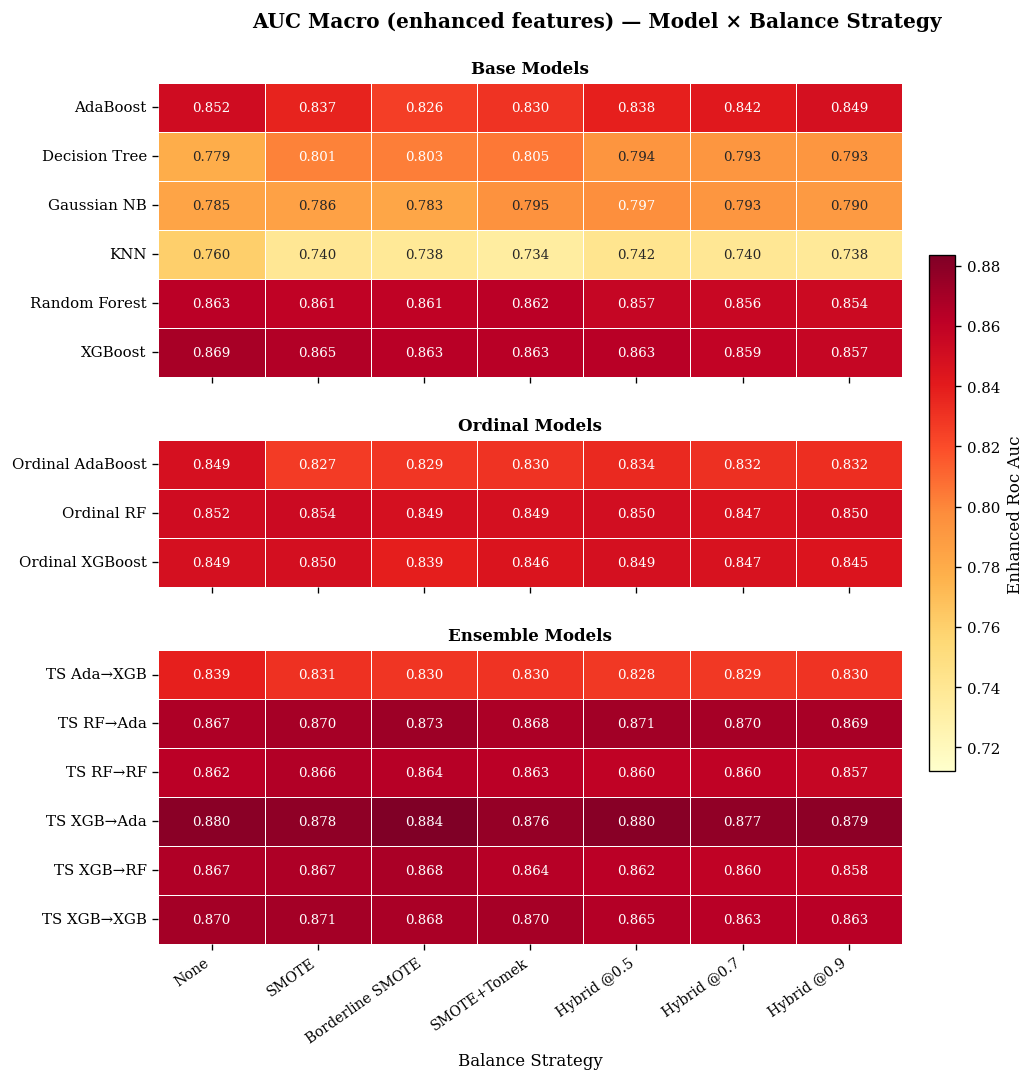

✓ Saved fig_heatmap_auc_enhanced.png


In [9]:
# ── Tune these ──────────────────────────────────────────────
CELL_W  = 0.95   # inches per column-cell
CELL_H  = 0.45   # inches per row-cell
PAD_TOP = 0.75   # inches for suptitle
PAD_MID = 0.70   # inches between panels
CBAR_W  = 0.6    # inches for colorbar region
# ────────────────────────────────────────────────────────────


def _heatmap(metric_col, title, fname):
    pivot = (
        agg.pivot_table(
            index   = "model",
            columns = "strategy_label",
            values  = metric_col,
            aggfunc = "max",
        )
        .reindex(index=ALL_MODELS, columns=STRATEGY_ORDER)
        .rename(index=MODEL_DISPLAY)
        .rename(columns=STRATEGY_LABELS)
    )

    n_base = len(BASE_MODELS)
    n_ord  = len(ORDINAL_MODELS)
    families = [
        ("Base Models",     pivot.iloc[:n_base, :]),
        ("Ordinal Models",  pivot.iloc[n_base:n_base + n_ord, :]),
        ("Ensemble Models", pivot.iloc[n_base + n_ord:, :]),
    ]

    vmin = pivot.values.min() * 0.97
    vmax = pivot.values.max()
    cbar_label = metric_col.replace("_macro", "").replace("_", " ").title()

    n_cols   = pivot.shape[1]
    max_rows = max(sub.shape[0] for _, sub in families)

    panel_w = n_cols * CELL_W
    fig_w   = panel_w + CBAR_W + 2.5
    fig_h   = sum(sub.shape[0] for _, sub in families) * CELL_H + 2 * PAD_MID + PAD_TOP

    row_counts = [sub.shape[0] for _, sub in families]
    fig, axes  = plt.subplots(
        3, 1, figsize=(fig_w, fig_h),
        gridspec_kw={"height_ratios": row_counts},
    )
    plt.subplots_adjust(
        hspace=PAD_MID / (max_rows * CELL_H),
        top=1 - PAD_TOP / fig_h,
    )

    for ax, (family_name, sub_pivot) in zip(axes, families):
        sns.heatmap(
            sub_pivot,
            ax=ax, annot=True, fmt=".3f",
            cmap="YlOrRd", linewidths=0.4, linecolor="white",
            vmin=vmin, vmax=vmax,
            annot_kws={"size": 8},
            cbar=False,
        )
        ax.set_title(family_name, fontweight="bold", fontsize=10, pad=6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    for ax in axes[:-1]:
        ax.set_xticklabels([])
    axes[-1].set_xlabel("Balance Strategy")

    # Single shared colorbar spanning all panels
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.6, pad=0.03)
    cbar.set_label(cbar_label, fontsize=10)

    fig.suptitle(title, fontweight="bold", fontsize=12, y=1 - 0.15 / fig_h)
    plt.savefig(OUTPUT_DIR / fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✓ Saved {fname}")


_heatmap("enhanced_f1_macro",      "F1 Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_f1_enhanced.png")
_heatmap("baseline_f1_macro",      "F1 Macro (baseline features) — Model × Balance Strategy",
         "fig_heatmap_f1_baseline.png")
_heatmap("enhanced_roc_auc_macro", "AUC Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_auc_enhanced.png")

## Section 8 — Confusion Matrices for Top-3 Models

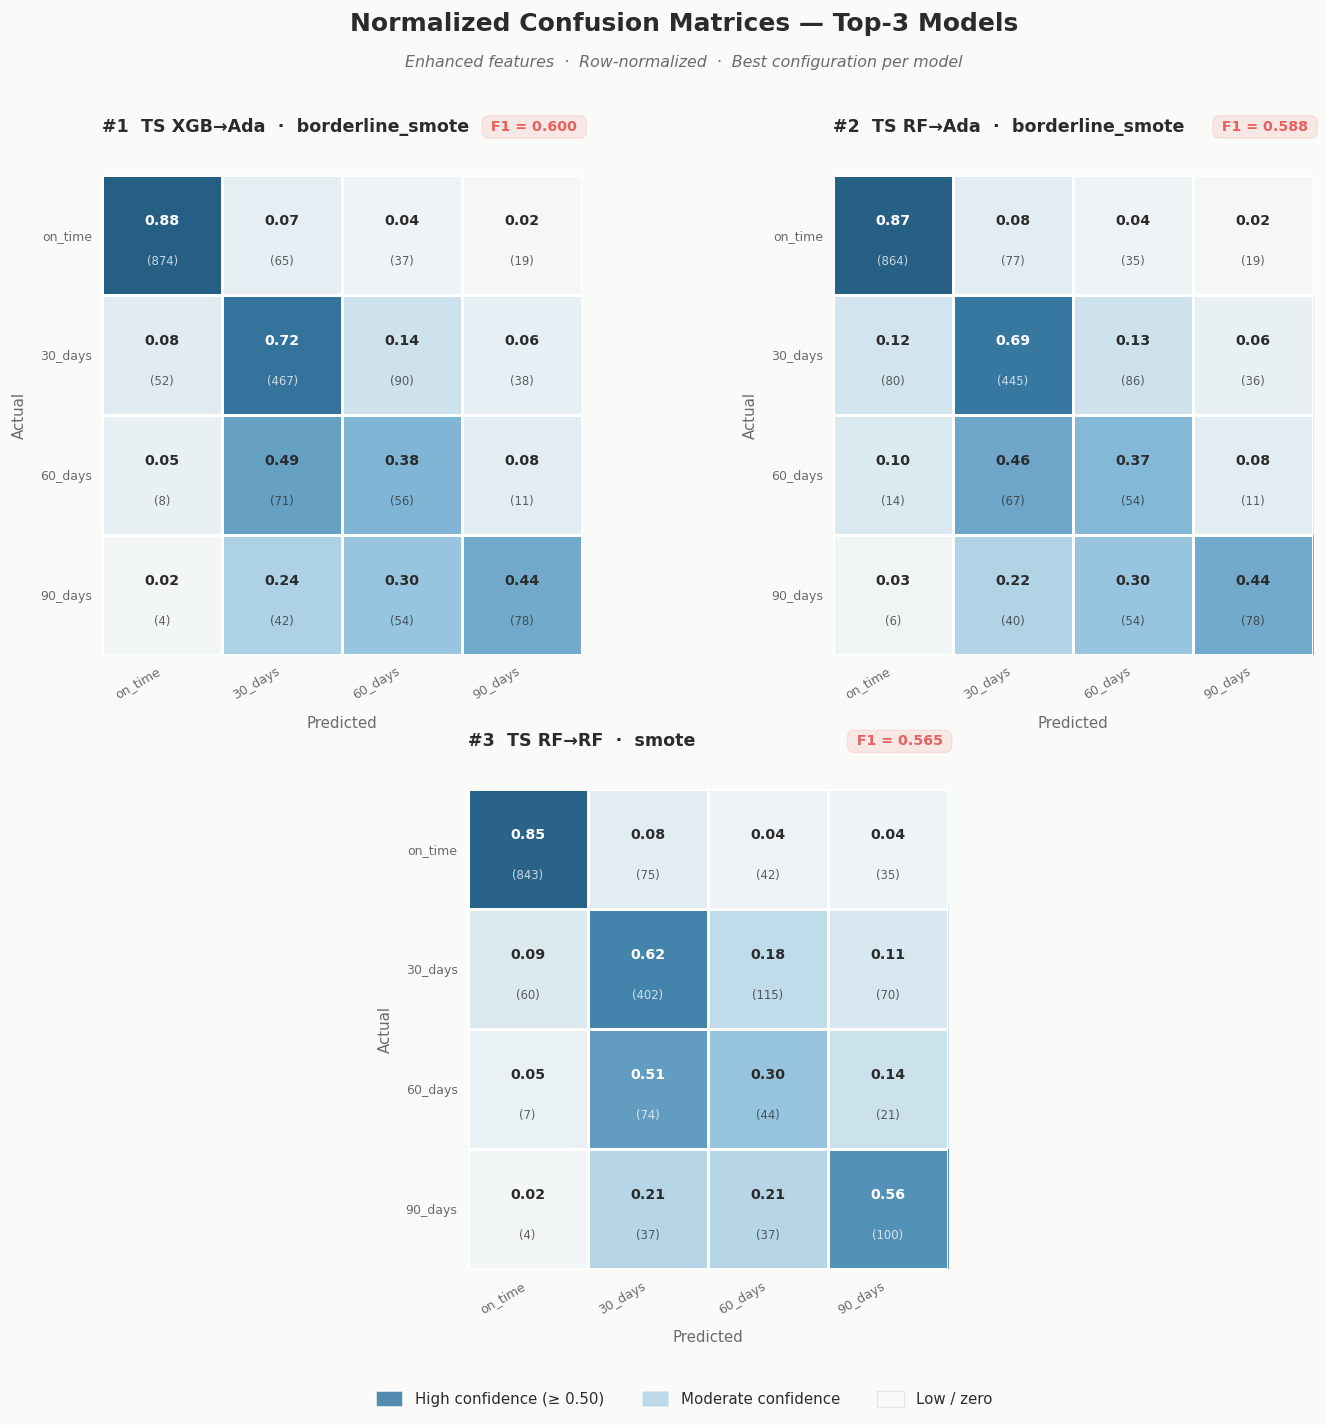

✓ Saved fig_confusion_matrices_top3.png


In [10]:
"""
Confusion matrices for top-3 models — 2×2 grid (2 top, 1 centred bottom).
Pulls confusion matrices dynamically from the SQLite results database,
pinned to the correct experiment_id from best_per_model to avoid ambiguity.
"""

import sqlite3
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# ── Design tokens (imported from theme; local aliases for clarity) ────────────
from src.modules.machine_learning.utils.io.analysis.visualization.theme import (
    SURV_COLOR, SURV_LIGHT, NOSURV_COLOR, NOSURV_LIGHT,
    BG_COLOR, GRID_COLOR, TEXT_DARK, TEXT_MID, CM_CMAP,
)

Theme.apply("publication")


# ── Badge helper ──────────────────────────────────────────────────────────────
def draw_metric_badge(ax, label_text, color, y=1.14):
    bbox_props = dict(
        boxstyle="round,pad=0.3,rounding_size=0.5",
        facecolor=color, edgecolor=color,
        alpha=0.12, linewidth=0.8,
    )
    ax.text(
        1.0, y, f" {label_text} ",
        transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, fontweight="bold", color=color,
        bbox=bbox_props, clip_on=False, zorder=10,
    )


# ── Styled confusion-matrix painter ──────────────────────────────────────────
def _plot_cm(matrix_raw, title, ax, class_labels, f1_score=None):
    cm      = np.array(matrix_raw, dtype=float)
    n       = cm.shape[0]
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    ax.imshow(cm_norm, cmap=CM_CMAP, vmin=0, vmax=1, aspect="equal")

    # White grid lines between cells
    for edge in range(n + 1):
        ax.axhline(edge - 0.5, color="white", linewidth=1.8, zorder=2)
        ax.axvline(edge - 0.5, color="white", linewidth=1.8, zorder=2)

    # Annotate each cell with normalised % (top) and raw count (bottom)
    for i in range(n):
        for j in range(n):
            pct   = cm_norm[i, j]
            count = int(cm[i, j])
            color = "white" if pct > 0.50 else TEXT_DARK
            ax.text(j, i - 0.12, f"{pct:.2f}",
                    ha="center", va="center", color=color,
                    fontsize=8.5, fontweight="bold", zorder=3)
            ax.text(j, i + 0.22, f"({count})",
                    ha="center", va="center", color=color,
                    fontsize=7, alpha=0.75, zorder=3)

    # Strip trailing "(N)" count suffixes from label strings if present
    clean_labels = [re.sub(r"\s*\(\d+\)\s*$", "", c) for c in class_labels]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(clean_labels, rotation=30, ha="right", fontsize=7.5, color=TEXT_MID)
    ax.set_yticklabels(clean_labels, fontsize=7.5, color=TEXT_MID)
    ax.tick_params(axis="both", length=0, pad=6)
    ax.set_xlabel("Predicted", fontsize=9, color=TEXT_MID, labelpad=8)
    ax.set_ylabel("Actual",    fontsize=9, color=TEXT_MID, labelpad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Title (left-aligned above the matrix) + optional F1 badge (right-aligned)
    HEADER_Y = 1.10
    ax.text(0.0, HEADER_Y, title,
            transform=ax.transAxes, ha="left", va="center",
            fontsize=10.5, fontweight="bold", color=TEXT_DARK,
            clip_on=False, zorder=10)
    if f1_score is not None:
        draw_metric_badge(ax, f"F1 = {f1_score:.3f}", SURV_COLOR, y=HEADER_Y)


# ── Dynamic data: pull confusion matrices from the SQLite database ────────────
class_labels = sorted(class_mappings.keys(), key=lambda k: class_mappings[k])

conn   = sqlite3.connect(DB_PATH)
top3   = best_per_model.head(3)

# Debug: uncomment these two lines if you hit column errors again
# print("best_per_model columns:", top3.columns.tolist())
# print("best_per_model index name:", top3.index.name)

models = []

for rank, (_, row) in enumerate(top3.iterrows(), start=1):
    model_key    = row["model"]
    strategy     = row.get("balance_strategy", "none")
    display      = row["model_display"]
    f1           = row["enhanced_f1_macro"]
    strategy_lbl = row.get("strategy_label", strategy)

    # FIX: experiment_id is not guaranteed to be a column in best_per_model.
    # Instead, resolve it from the database directly: find the single experiment
    # for this (model, balance_strategy) pair whose enhanced f1_macro matches
    # the value already selected by best_per_model. This avoids any ambiguity
    # from the old LIMIT 1 approach while not depending on a column that may
    # not exist in the DataFrame.
    exp_id_row = conn.execute(
        """
        SELECT e.id
        FROM experiments e
        JOIN metrics m ON m.experiment_id = e.id
        WHERE e.model            = ?
          AND e.balance_strategy = ?
          AND m.phase            = 'enhanced'
          AND ROUND(m.f1_macro, 10) = ROUND(?, 10)
        LIMIT 1
        """,
        (model_key, strategy, f1),
    ).fetchone()

    if exp_id_row is None:
        print(f"⚠ Could not resolve experiment_id for {display} / {strategy} "
              f"(f1={f1:.4f}), skipping")
        continue

    exp_id = exp_id_row[0]

    # Now fetch the chart pinned to the exact experiment — no ambiguity
    result = conn.execute(
        """
        SELECT c.data
        FROM charts c
        WHERE c.experiment_id = ?
          AND c.phase         = 'enhanced'
          AND c.chart_type    = 'confusion_matrix'
        """,
        (exp_id,),
    ).fetchone()

    if result is None:
        print(f"⚠ No confusion matrix found for {display} / {strategy} "
              f"(exp_id={exp_id}), skipping")
        continue

    # Parse the JSON blob — support both bare list and dict wrapper formats
    cm_data = json.loads(result[0])
    if isinstance(cm_data, list):
        cm_matrix = cm_data
    elif isinstance(cm_data, dict):
        cm_matrix = cm_data.get("matrix", cm_data.get("data", cm_data.get("values")))
        if cm_matrix is None:
            print(f"⚠ Could not find matrix key in CM dict for {display} "
                  f"(exp_id={exp_id}), skipping. Keys found: {list(cm_data.keys())}")
            continue
    else:
        print(f"⚠ Unexpected confusion matrix format ({type(cm_data)}) "
              f"for {display} (exp_id={exp_id}), skipping")
        continue

    models.append({
        "title":  f"#{rank}  {display}  ·  {strategy_lbl}",
        "f1":     f1,
        "matrix": cm_matrix,
    })

conn.close()

if len(models) == 0:
    raise RuntimeError(
        "No confusion matrices found in the database — "
        "check that experiment_id values exist in the charts table."
    )

# ── Build the figure ──────────────────────────────────────────────────────────
n_models = len(models)

if n_models == 3:
    # 2-top / 1-centred-bottom layout using a 2×4 gridspec
    fig  = plt.figure(figsize=(13, 12), facecolor=BG_COLOR)
    gs   = fig.add_gridspec(2, 4, hspace=0.28, wspace=0.40,
                            left=0.08, right=0.95, top=0.86, bottom=0.10)
    axes = [
        fig.add_subplot(gs[0, 0:2]),   # top-left
        fig.add_subplot(gs[0, 2:4]),   # top-right
        fig.add_subplot(gs[1, 1:3]),   # bottom-centre
    ]
elif n_models == 2:
    fig  = plt.figure(figsize=(13, 7), facecolor=BG_COLOR)
    gs   = fig.add_gridspec(1, 4, wspace=0.40,
                            left=0.08, right=0.95, top=0.86, bottom=0.10)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
    ]
else:  # n_models == 1
    fig  = plt.figure(figsize=(7, 7), facecolor=BG_COLOR)
    axes = [fig.add_subplot(111)]

for ax_idx, model in enumerate(models):
    _plot_cm(model["matrix"], model["title"], axes[ax_idx],
             class_labels=class_labels, f1_score=model["f1"])

# ── Figure-level title and subtitle ──────────────────────────────────────────
fig.text(0.5, 0.96, f"Normalized Confusion Matrices — Top-{n_models} Models",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 0.935,
         "Enhanced features  ·  Row-normalized  ·  Best configuration per model",
         ha="center", fontsize=9.5, color=TEXT_MID, fontstyle="italic")

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=NOSURV_COLOR, alpha=0.88, edgecolor="white",
                   label="High confidence (≥ 0.50)"),
    mpatches.Patch(facecolor=NOSURV_LIGHT, alpha=0.55, edgecolor="white",
                   label="Moderate confidence"),
    mpatches.Patch(facecolor=BG_COLOR, edgecolor=GRID_COLOR, linewidth=0.8,
                   label="Low / zero"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.005),
           handlelength=1.8, handleheight=1.2, columnspacing=2.5)

# ── Save and display ──────────────────────────────────────────────────────────
plt.savefig(OUTPUT_DIR / "fig_confusion_matrices_top3.png",
            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
plt.show()
print("✓ Saved fig_confusion_matrices_top3.png")

In [11]:
"""
debug_cm.py — Confusion Matrix loading diagnostics
===================================================
Run from your repo root:
    python debug_cm.py

Checks:
  1. How many confusion-matrix rows exist per (model, balance_strategy) combo
  2. Whether the experiment_id used in the query actually matches best_per_model
  3. Whether two top models are accidentally resolving to the same DB row
  4. Prints a side-by-side diff of what the plot loaded vs what the DB contains
"""

from __future__ import annotations
import sqlite3
import json
import sys
from pathlib import Path

# ── Configure these to match your notebook ────────────────────────────────────
DB_PATH = "data/training_results/2026_05_09_02/results.db"   # ← adjust if needed
TOP_N   = 3   # number of models to inspect

# ── Connect ───────────────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row


# ════════════════════════════════════════════════════════════════════════════════
# STEP 1 — Reproduce best_per_model (mirrors notebook Section 4)
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 1: best_per_model (top experiments by enhanced_f1_macro per model)")
print("=" * 70)

# Inspect schema of experiments and metrics tables
schema_experiments = conn.execute("PRAGMA table_info(experiments)").fetchall()
schema_metrics = conn.execute("PRAGMA table_info(metrics)").fetchall()

print([col["name"] for col in schema_metrics])

best_rows = conn.execute("""
    SELECT
        e.id                 AS exp_id,
        e.model,
        e.balance_strategy,
        e.undersample_threshold,
        MAX(m.f1_macro)      AS best_f1
    FROM experiments e
    JOIN metrics m
      ON m.experiment_id = e.id
     AND m.phase         = 'enhanced'
    GROUP BY e.model
    ORDER BY best_f1 DESC
    LIMIT ?
""", (TOP_N,)).fetchall()


for r in best_rows:
    strategy = r["balance_strategy"]
    thr      = r["undersample_threshold"]
    strat_label = f"hybrid@{thr:.1f}" if strategy == "hybrid" and thr else strategy
    print(f"  #{list(best_rows).index(r)+1}  exp_id={r['exp_id']:<6}  "
          f"model={r['model']:<28}  strategy={strat_label:<18}  F1={r['best_f1']:.4f}")

print()


# ════════════════════════════════════════════════════════════════════════════════
# STEP 2 — Count CM rows per (model, balance_strategy) — reveals ambiguity
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 2: Confusion-matrix row counts per (model, balance_strategy)")
print("        > 1 means the old query (no experiment_id pin) is ambiguous")
print("=" * 70)

for r in best_rows:
    rows = conn.execute("""
        SELECT c.experiment_id, e.balance_strategy, e.undersample_threshold, c.phase
        FROM charts c
        JOIN experiments e ON c.experiment_id = e.id
        WHERE e.model       = ?
          AND e.balance_strategy = ?
          AND c.phase       = 'enhanced'
          AND c.chart_type  = 'confusion_matrix'
    """, (r["model"], r["balance_strategy"])).fetchall()

    flag = "  ✓" if len(rows) == 1 else f"  ⚠  AMBIGUOUS — {len(rows)} rows match"
    print(f"\n  model={r['model']}  strategy={r['balance_strategy']}{flag}")
    for row in rows:
        match = "← THIS exp_id" if row["experiment_id"] == r["exp_id"] else ""
        print(f"      experiment_id={row['experiment_id']}  phase={row['phase']}  {match}")

print()


# ════════════════════════════════════════════════════════════════════════════════
# STEP 3 — Check for duplicate/identical CM data across the top-N models
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 3: Are any top-N confusion matrices identical? (data-level dedup)")
print("=" * 70)

cm_blobs: dict[int, str] = {}
for r in best_rows:
    row = conn.execute("""
        SELECT c.data, c.experiment_id
        FROM charts c
        JOIN experiments e ON c.experiment_id = e.id
        WHERE e.model           = ?
          AND e.balance_strategy = ?
          AND c.phase           = 'enhanced'
          AND c.chart_type      = 'confusion_matrix'
        LIMIT 1
    """, (r["model"], r["balance_strategy"])).fetchone()

    if row:
        cm_blobs[r["exp_id"]] = row["data"]
        resolved_to = row["experiment_id"]
        match_flag  = "" if resolved_to == r["exp_id"] else (
            f"  ⚠  RESOLVED TO WRONG exp_id={resolved_to}  (expected {r['exp_id']})"
        )
        print(f"  model={r['model']}{match_flag}")

seen: dict[str, int] = {}
for exp_id, blob in cm_blobs.items():
    if blob in seen:
        print(f"  ⚠  exp_id={exp_id} has IDENTICAL CM data to exp_id={seen[blob]}")
    else:
        seen[blob] = exp_id

if len(seen) == len(cm_blobs):
    print("  ✓ All CM blobs are distinct")

print()


# ════════════════════════════════════════════════════════════════════════════════
# STEP 4 — Print actual matrix values for visual inspection
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 4: Actual confusion matrix values loaded by the BUGGY query")
print("        (LIMIT 1 without experiment_id pin — may be wrong experiment)")
print("=" * 70)

for rank, r in enumerate(best_rows, 1):
    row = conn.execute("""
        SELECT c.data, c.experiment_id
        FROM charts c
        JOIN experiments e ON c.experiment_id = e.id
        WHERE e.model           = ?
          AND e.balance_strategy = ?
          AND c.phase           = 'enhanced'
          AND c.chart_type      = 'confusion_matrix'
        LIMIT 1
    """, (r["model"], r["balance_strategy"])).fetchone()

    if not row:
        print(f"  #{rank} {r['model']}: NO CM FOUND")
        continue

    cm_data = json.loads(row["data"])
    matrix  = (cm_data if isinstance(cm_data, list)
               else cm_data.get("matrix", cm_data.get("data", cm_data.get("values"))))

    resolved_id = row["experiment_id"]
    correct     = resolved_id == r["exp_id"]
    flag        = "✓" if correct else f"⚠  WRONG (got exp_id={resolved_id}, want {r['exp_id']})"

    print(f"\n  #{rank}  {r['model']} / {r['balance_strategy']}  [{flag}]")
    print(f"  Diagonal (row-normalised):")
    import numpy as np
    cm   = np.array(matrix, dtype=float)
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    for i, row_vals in enumerate(norm):
        diag_val = f"{row_vals[i]:.3f}"
        print(f"    class {i}: diag={diag_val}  counts={[int(v) for v in cm[i]]}")

print()


# ════════════════════════════════════════════════════════════════════════════════
# STEP 5 — Print CORRECT matrix values (pinned by experiment_id)
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 5: Actual confusion matrix values loaded by the FIXED query")
print("        (pinned to the correct experiment_id from best_per_model)")
print("=" * 70)

for rank, r in enumerate(best_rows, 1):
    row = conn.execute("""
        SELECT c.data
        FROM charts c
        WHERE c.experiment_id = ?
          AND c.phase         = 'enhanced'
          AND c.chart_type    = 'confusion_matrix'
    """, (r["exp_id"],)).fetchone()

    if not row:
        print(f"  #{rank} exp_id={r['exp_id']}: NO CM FOUND — chart may be stored under a different exp_id")
        continue

    cm_data = json.loads(row["data"])
    matrix  = (cm_data if isinstance(cm_data, list)
               else cm_data.get("matrix", cm_data.get("data", cm_data.get("values"))))

    import numpy as np
    cm   = np.array(matrix, dtype=float)
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    print(f"\n  #{rank}  {r['model']} / {r['balance_strategy']}  (exp_id={r['exp_id']})")
    for i, row_vals in enumerate(norm):
        diag_val = f"{row_vals[i]:.3f}"
        print(f"    class {i}: diag={diag_val}  counts={[int(v) for v in cm[i]]}")

print()


# ════════════════════════════════════════════════════════════════════════════════
# STEP 6 — Inspect the charts table schema and experiment_id linkage
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 6: charts table — schema and row counts")
print("=" * 70)

schema = conn.execute(
    "SELECT sql FROM sqlite_master WHERE type='table' AND name='charts'"
).fetchone()
print(f"  Schema: {schema[0] if schema else 'NOT FOUND'}\n")

counts = conn.execute("""
    SELECT chart_type, phase, COUNT(*) AS n
    FROM charts
    GROUP BY chart_type, phase
    ORDER BY chart_type, phase
""").fetchall()
for row in counts:
    print(f"  chart_type={row[0]:<25} phase={row[1]:<12} n={row[2]}")

conn.close()

print()
print("=" * 70)
print("DIAGNOSIS COMPLETE")
print()
print("Fix to apply in Section 8 of ML_Results_Analysis.py:")
print()
print("  Replace the query:")
print("    WHERE e.model = ? AND e.balance_strategy = ?")
print()
print("  With the experiment_id-pinned version:")
print("    WHERE c.experiment_id = <exp_id from best_per_model>")
print("      AND c.phase = 'enhanced'")
print("      AND c.chart_type = 'confusion_matrix'")
print("=" * 70)

STEP 1: best_per_model (top experiments by enhanced_f1_macro per model)
['id', 'experiment_id', 'phase', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro']
  #1  exp_id=814     model=two_stage_xgb_ada             strategy=borderline_smote    F1=0.6003
  #2  exp_id=287     model=two_stage_rf_ada              strategy=borderline_smote    F1=0.5880
  #3  exp_id=154     model=two_stage_rf_rf               strategy=smote               F1=0.5646

STEP 2: Confusion-matrix row counts per (model, balance_strategy)
        > 1 means the old query (no experiment_id pin) is ambiguous

  model=two_stage_xgb_ada  strategy=borderline_smote  ⚠  AMBIGUOUS — 10 rows match
      experiment_id=809  phase=enhanced  
      experiment_id=810  phase=enhanced  
      experiment_id=811  phase=enhanced  
      experiment_id=812  phase=enhanced  
      experiment_id=813  phase=enhanced  
      experiment_id=814  phase=enhanced  ← THIS exp_id
      experiment_id=815  phase=enhanced  
     

## Section 9 — ROC Curves for Top Models

=== Top-5 by enhanced AUC (ROC curves will be plotted) ===
    id model_display    strategy_label  enhanced_roc_auc_macro
1  817    TS XGB→Ada  borderline_smote                0.883542
2  814    TS XGB→Ada  borderline_smote                0.881909
3  946    TS XGB→Ada        hybrid@0.5                0.880213
4  811    TS XGB→Ada  borderline_smote                0.880110
5  816    TS XGB→Ada  borderline_smote                0.879968


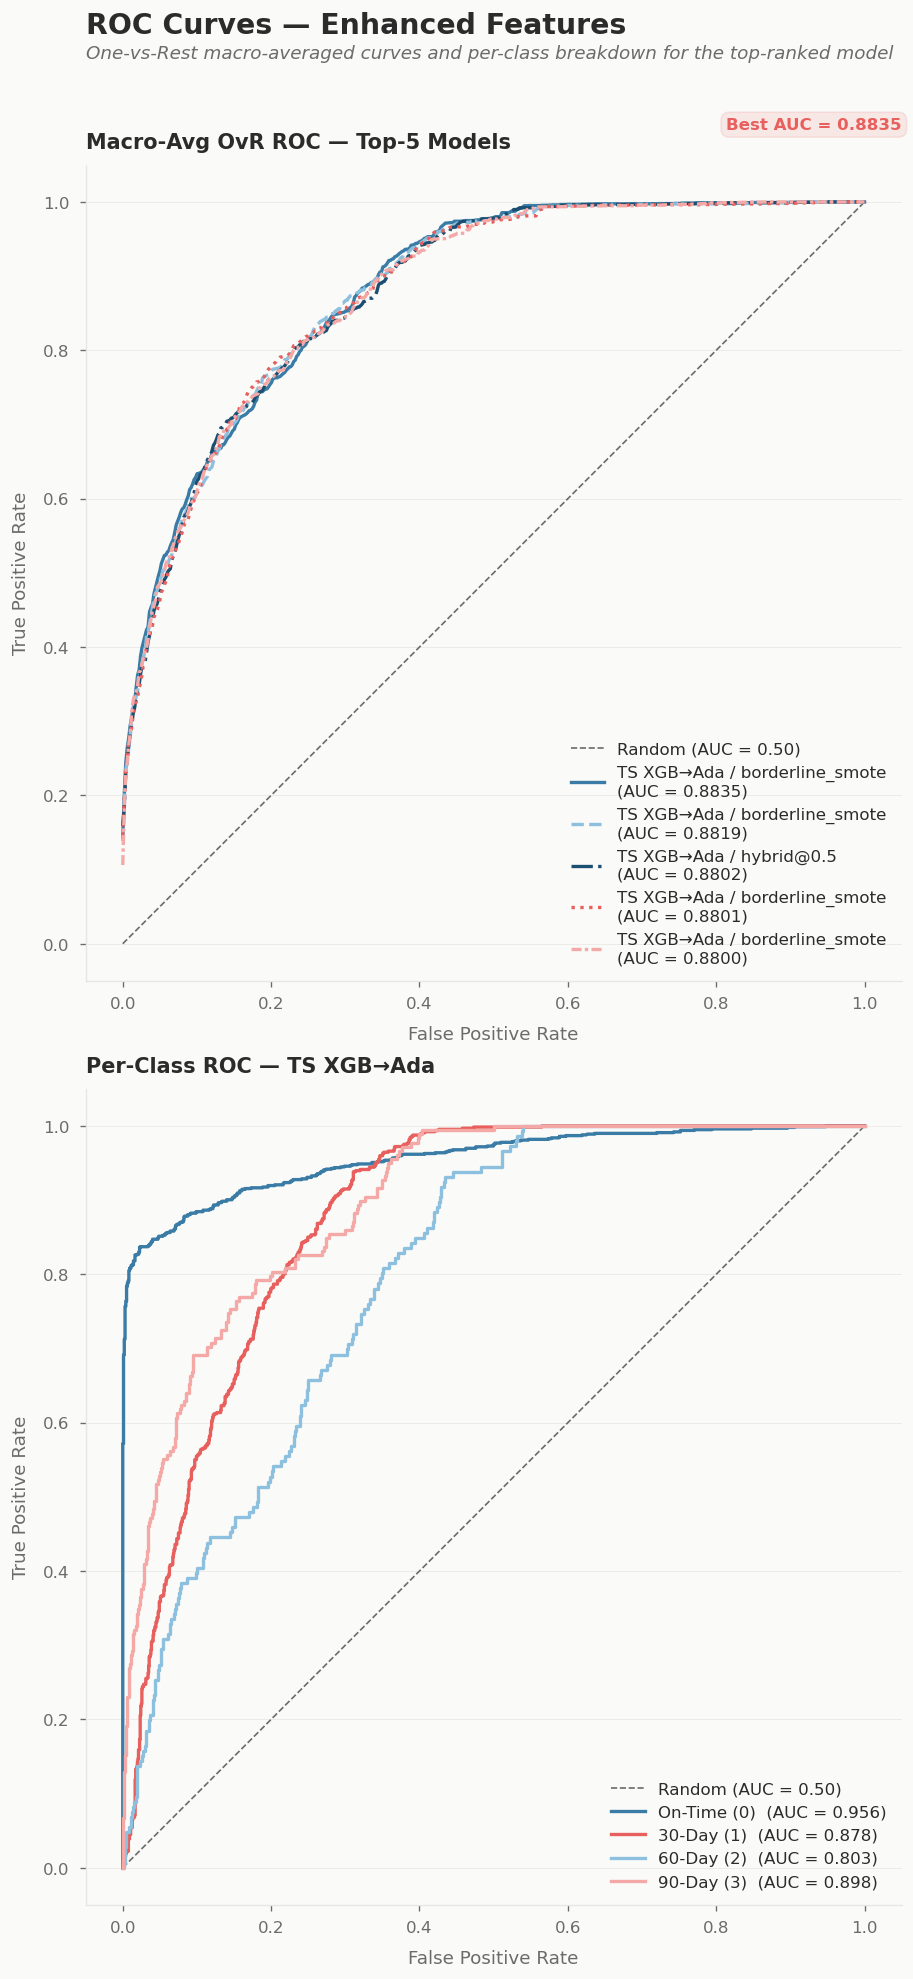

✓ Saved fig_roc_curves.png


In [12]:
import sqlite3
import json
import matplotlib.gridspec as gridspec

# ── Design tokens from theme ──────────────────────────────────────────────────
from src.modules.machine_learning.utils.io.analysis.visualization.theme import (
    SURV_COLOR, NOSURV_COLOR, NOSURV_LIGHT, BG_COLOR, GRID_COLOR,
    TEXT_DARK, TEXT_MID, DEEP_BLUE, SURV_LIGHT,
    LINE_COLORS, LINE_STYLES, CLASS_COLORS,
)

Theme.apply("publication")

# ── Top-5 models by AUC ───────────────────────────────────────────────────────
top5_auc = (
    ra.top(5, by="enhanced_roc_auc_macro")
      .df[["id", "model_display", "strategy_label", "enhanced_roc_auc_macro"]]
      .reset_index(drop=True)
)
top5_auc.index += 1
print("=== Top-5 by enhanced AUC (ROC curves will be plotted) ===")
print(top5_auc.to_string())

top5_ids = top5_auc["id"].tolist()
ph = ",".join(["?"] * len(top5_ids))

with sqlite3.connect(DB_PATH) as roc_conn:
    roc_rows = pd.read_sql(
        f"SELECT experiment_id, data FROM charts "
        f"WHERE chart_type='roc_curve' AND phase='enhanced' AND experiment_id IN ({ph})",
        roc_conn, params=top5_ids,
    )

FPR_GRID = np.linspace(0, 1, 500)

# ── Figure setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 16), facecolor=BG_COLOR)
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0,
                        left=0.10, right=0.95, top=0.90, bottom=0.05)

ax_macro = fig.add_subplot(gs[0])
ax_class = fig.add_subplot(gs[1])

fig.canvas.draw()
gap_frac = 0.9 / fig.get_figheight()
pos_macro = ax_macro.get_position()
ax_class.set_position([
    pos_macro.x0,
    pos_macro.y0 - gap_frac - pos_macro.height,
    pos_macro.width,
    pos_macro.height,
])


def _style_ax(ax, xlabel="False Positive Rate", ylabel="True Positive Rate"):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=11, color=TEXT_MID, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, color=TEXT_MID, labelpad=8)
    ax.tick_params(labelsize=10, colors=TEXT_MID, pad=6)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1,
            color=TEXT_MID, label="Random (AUC = 0.50)")


_style_ax(ax_macro)
_style_ax(ax_class)

# ── Panel 1: Macro-averaged OvR ROC — Top-5 models ───────────────────────────
best_macro_auc = best_model_label = None

for idx, (_, row_info) in enumerate(top5_auc.iterrows()):
    exp_id  = row_info["id"]
    roc_row = roc_rows[roc_rows["experiment_id"] == exp_id]
    if roc_row.empty:
        continue

    roc_data    = json.loads(roc_row.iloc[0]["data"])
    tpr_interps = [
        np.interp(FPR_GRID, np.array(roc_data[k]["fpr"]), np.array(roc_data[k]["tpr"]))
        for k in sorted(roc_data.keys(), key=int)
    ]
    macro_tpr = np.mean(tpr_interps, axis=0)
    macro_auc = row_info["enhanced_roc_auc_macro"]

    label = (
        f"{row_info['model_display']} / {row_info['strategy_label']}"
        f"\n(AUC = {macro_auc:.4f})"
    )
    ax_macro.plot(FPR_GRID, macro_tpr,
                  linestyle=LINE_STYLES[idx], color=LINE_COLORS[idx],
                  linewidth=2, label=label)

    if idx == 0:
        best_macro_auc   = macro_auc
        best_model_label = row_info["model_display"]

ax_macro.set_title("Macro-Avg OvR ROC — Top-5 Models",
                   fontsize=12.5, fontweight="bold", color=TEXT_DARK, loc="left", pad=10)

if best_macro_auc is not None:
    ax_macro.text(
        1.0, 1.04, f"Best AUC = {best_macro_auc:.4f}",
        transform=ax_macro.transAxes, ha="right", va="bottom",
        fontsize=10, fontweight="bold", color=SURV_COLOR,
        bbox=dict(boxstyle="round,pad=0.3,rounding_size=0.5",
                  facecolor=SURV_COLOR, alpha=0.12, edgecolor=SURV_COLOR),
    )

ax_macro.legend(fontsize=10, loc="lower right", frameon=False)

# ── Panel 2: Per-class ROC — best model ──────────────────────────────────────
best_id = top5_auc.loc[1, "id"]
roc_row = roc_rows[roc_rows["experiment_id"] == best_id]

if not roc_row.empty:
    roc_data = json.loads(roc_row.iloc[0]["data"])
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_key = str(cls_idx)
        if cls_key not in roc_data:
            continue
        cls_d   = roc_data[cls_key]
        fpr_arr = np.array(cls_d["fpr"])
        tpr_arr = np.array(cls_d["tpr"])
        cls_auc = cls_d.get("auc", float(np.trapezoid(tpr_arr, fpr_arr)))
        ax_class.plot(fpr_arr, tpr_arr, color=CLASS_COLORS[cls_idx],
                      linewidth=2, label=f"{cls_name}  (AUC = {cls_auc:.3f})")

best_display = top5_auc.loc[1, "model_display"]
ax_class.set_title(f"Per-Class ROC — {best_display}",
                   fontsize=12.5, fontweight="bold", color=TEXT_DARK, loc="left", pad=10)
ax_class.legend(fontsize=10, loc="lower right", frameon=False)

fig.text(0.10, 0.980, "ROC Curves — Enhanced Features",
         fontsize=17, fontweight="bold", color=TEXT_DARK, ha="left", va="top")
fig.text(0.10, 0.963,
         "One-vs-Rest macro-averaged curves and per-class breakdown for the top-ranked model",
         fontsize=11, color=TEXT_MID, fontstyle="italic", ha="left", va="top")

fig.savefig(OUTPUT_DIR / "fig_roc_curves.png",
            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
plt.show()
print("✓ Saved fig_roc_curves.png")

## Section 10 — Feature Importance Plots

✓ Saved fig_feature_importance.png


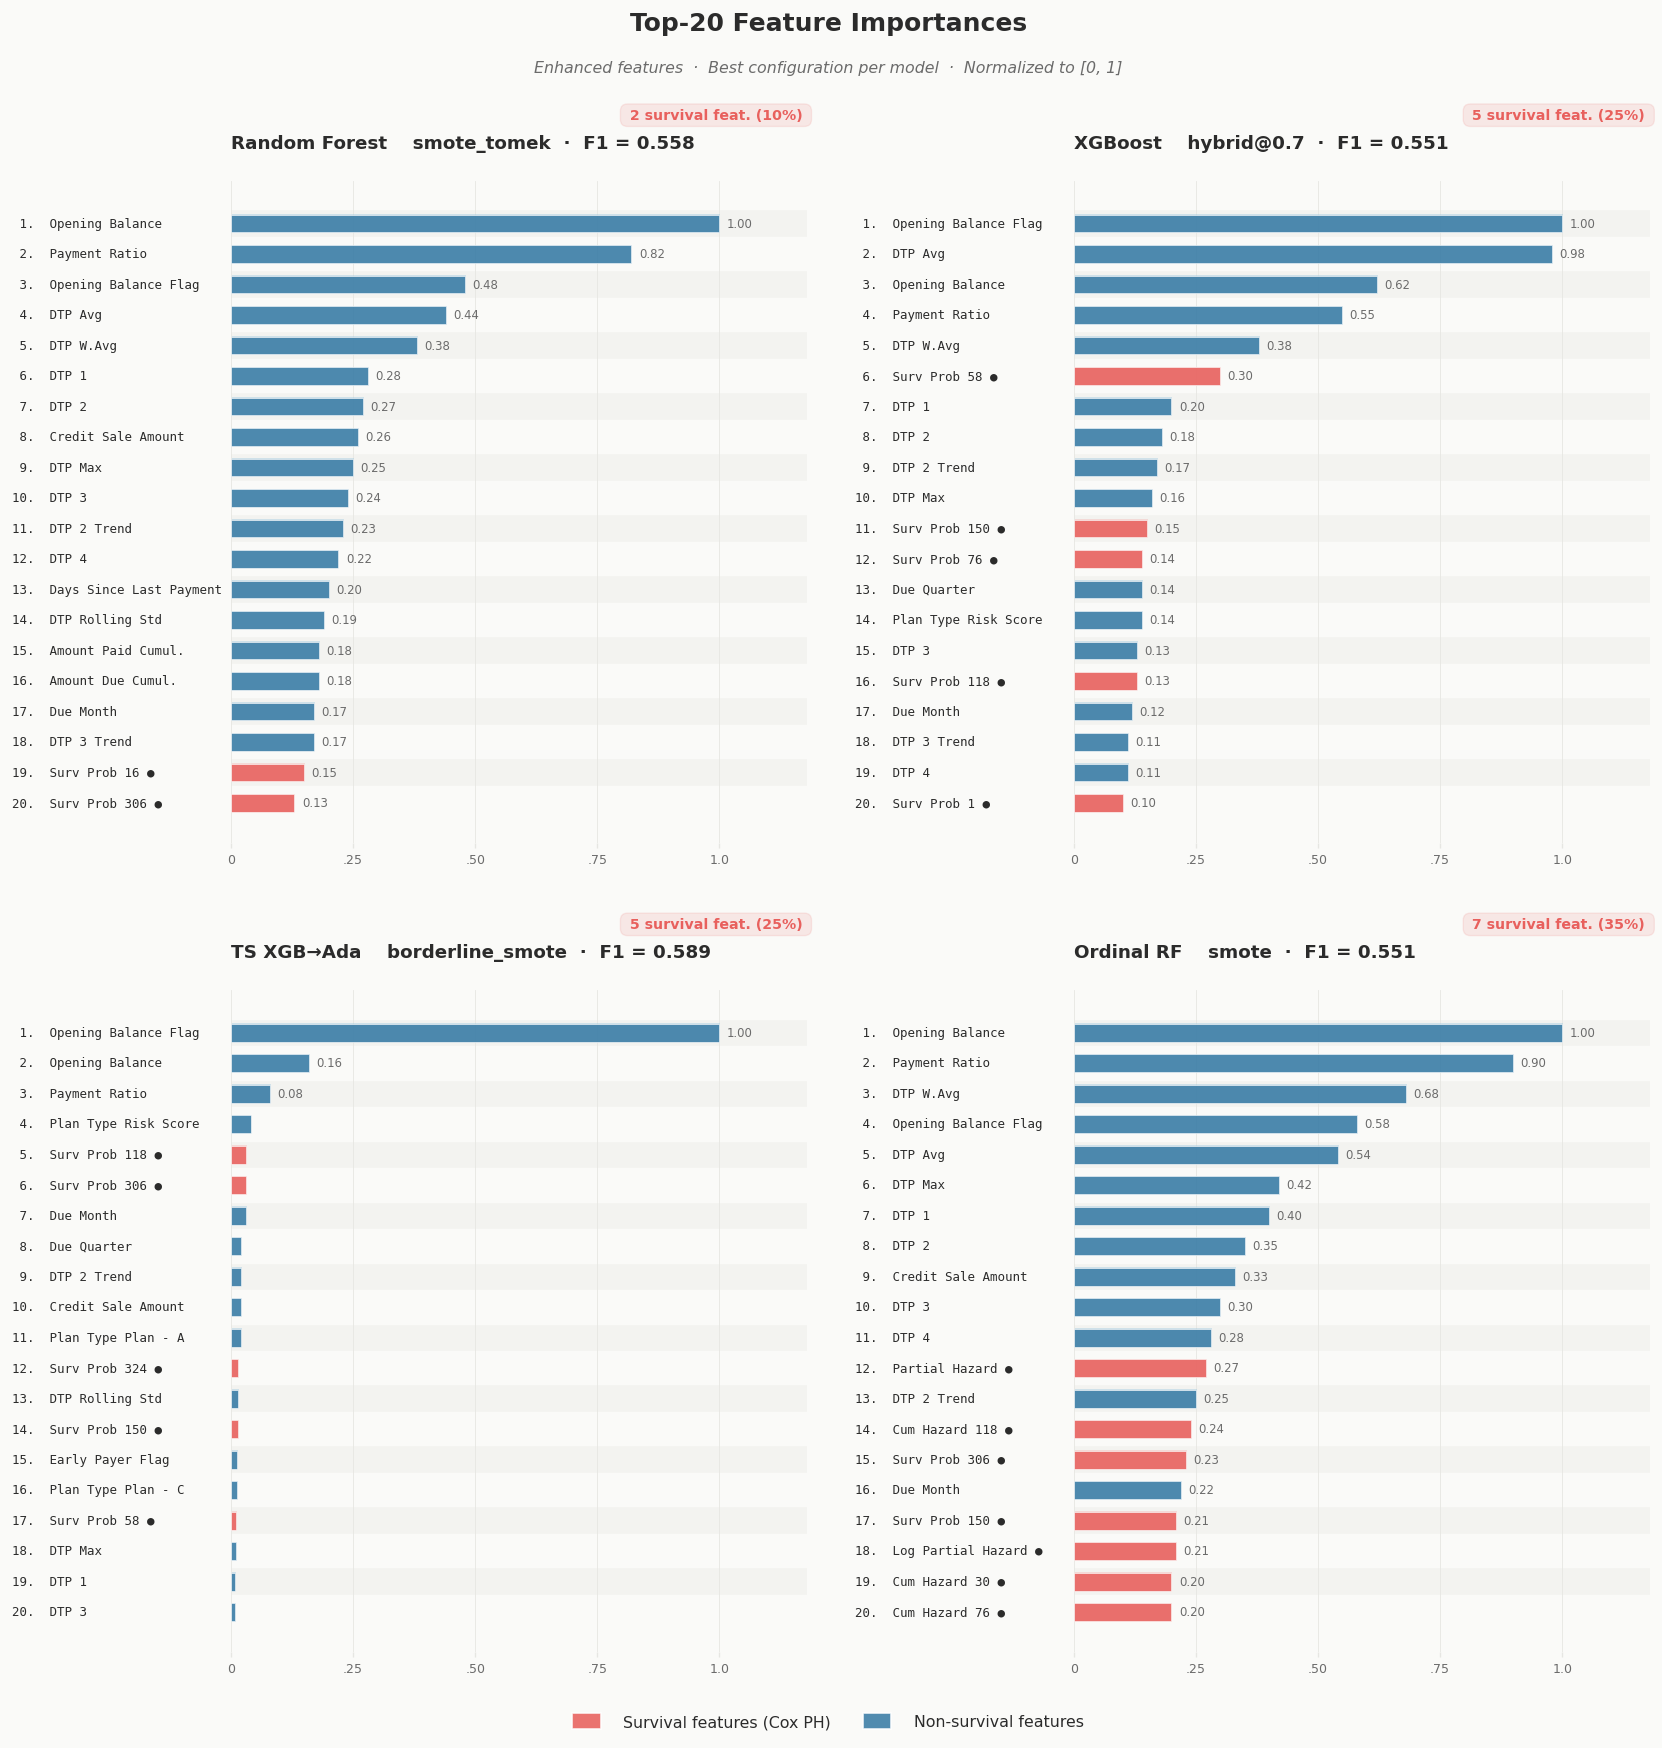

In [13]:
import re
import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms

# ── Design tokens from theme ──────────────────────────────────────────────────
from src.modules.machine_learning.utils.io.analysis.visualization.theme import (
    SURV_COLOR, SURV_LIGHT, NOSURV_COLOR, NOSURV_LIGHT,
    BG_COLOR, GRID_COLOR, TEXT_DARK, TEXT_MID, STRIPE_COLOR,
)

# SURVIVAL_FEATURES is imported from the analysis module at the top of the notebook.

FEAT_MODELS = ["random_forest", "xgboost", "two_stage_xgb_ada", "ordinal_random_forest"]

_DATA = {
    "random_forest": [
        ("opening_balance", 1.0), ("payment_ratio", 0.82), ("opening_balance_flag", 0.48),
        ("dtp_avg", 0.44), ("dtp_wavg", 0.38), ("dtp_1", 0.28), ("dtp_2", 0.27),
        ("credit_sale_amount", 0.26), ("dtp_max", 0.25), ("dtp_3", 0.24),
        ("dtp_2_trend", 0.23), ("dtp_4", 0.22), ("days_since_last_payment", 0.20),
        ("dtp_rolling_std", 0.19), ("amount_paid_cumsum", 0.18), ("amount_due_cumsum", 0.18),
        ("due_month", 0.17), ("dtp_3_trend", 0.17), ("surv_prob_16", 0.15), ("surv_prob_306", 0.13),
    ],
    "xgboost": [
        ("opening_balance_flag", 1.0), ("dtp_avg", 0.98), ("opening_balance", 0.62),
        ("payment_ratio", 0.55), ("dtp_wavg", 0.38), ("surv_prob_58", 0.30),
        ("dtp_1", 0.20), ("dtp_2", 0.18), ("dtp_2_trend", 0.17), ("dtp_max", 0.16),
        ("surv_prob_150", 0.15), ("surv_prob_76", 0.14), ("due_quarter", 0.14),
        ("plan_type_risk_score", 0.14), ("dtp_3", 0.13), ("surv_prob_118", 0.13),
        ("due_month", 0.12), ("dtp_3_trend", 0.11), ("dtp_4", 0.11), ("surv_prob_1", 0.10),
    ],
    "two_stage_xgb_ada": [
        ("opening_balance_flag", 1.0), ("opening_balance", 0.16), ("payment_ratio", 0.08),
        ("plan_type_risk_score", 0.04), ("surv_prob_118", 0.03), ("surv_prob_306", 0.03),
        ("due_month", 0.03), ("due_quarter", 0.02), ("dtp_2_trend", 0.02),
        ("credit_sale_amount", 0.02), ("plan_type_Plan - A", 0.02), ("surv_prob_324", 0.015),
        ("dtp_rolling_std", 0.015), ("surv_prob_150", 0.014), ("early_payer_flag", 0.013),
        ("plan_type_Plan - C", 0.012), ("surv_prob_58", 0.011), ("dtp_max", 0.010),
        ("dtp_1", 0.009), ("dtp_3", 0.008),
    ],
    "ordinal_random_forest": [
        ("opening_balance", 1.0), ("payment_ratio", 0.90), ("dtp_wavg", 0.68),
        ("opening_balance_flag", 0.58), ("dtp_avg", 0.54), ("dtp_max", 0.42),
        ("dtp_1", 0.40), ("dtp_2", 0.35), ("credit_sale_amount", 0.33), ("dtp_3", 0.30),
        ("dtp_4", 0.28), ("partial_hazard", 0.27), ("dtp_2_trend", 0.25),
        ("cum_hazard_118", 0.24), ("surv_prob_306", 0.23), ("due_month", 0.22),
        ("surv_prob_150", 0.21), ("log_partial_hazard", 0.21), ("cum_hazard_30", 0.20),
        ("cum_hazard_76", 0.20),
    ],
}

_META = {
    "random_forest":         ("smote_tomek",       0.558),
    "xgboost":               ("hybrid@0.7",        0.551),
    "two_stage_xgb_ada":     ("borderline_smote",  0.589),
    "ordinal_random_forest": ("smote",             0.551),
}


def _pretty(name: str) -> str:
    """Make raw feature names human-readable."""
    swaps = {
        "dtp": "DTP", "xgb": "XGB", "ada": "Ada", "rf": "RF",
        "avg": "Avg", "wavg": "W.Avg", "std": "Std",
        "cumsum": "Cumul.", "prob": "Prob", "cum": "Cum",
        "surv": "Surv", "ts": "TS",
    }
    out = name.replace("_", " ")
    for k, v in swaps.items():
        out = re.sub(rf'\b{k}\b', v, out, flags=re.IGNORECASE)
    tokens = out.split()
    final  = []
    for t in tokens:
        if t == t.upper() and len(t) > 1:
            final.append(t)
        elif t[0].isupper():
            final.append(t)
        else:
            final.append(t.capitalize())
    return " ".join(final)


def draw_badge(ax, surv_count, total):
    """Draw a colored pill/badge showing survival feature count."""
    surv_share = surv_count / total * 100
    label      = f" {surv_count} survival feat. ({surv_share:.0f}%) "
    ax.text(
        1.0, 1.10, label,
        transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, fontweight="bold", color=SURV_COLOR,
        bbox=dict(boxstyle="round,pad=0.3,rounding_size=0.5",
                  facecolor=SURV_COLOR, edgecolor=SURV_COLOR, alpha=0.12, linewidth=0.8),
        clip_on=False, zorder=10,
    )


Theme.apply("publication")
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes_flat = axes.flatten()

for idx, (ax, model_name) in enumerate(zip(axes_flat, FEAT_MODELS)):
    feat_weights = _DATA[model_name][:20]
    strategy, f1 = _META[model_name]

    features_raw = [f for f, _ in feat_weights]
    weights      = np.array([w for _, w in feat_weights], dtype=float)
    if weights.max() > 0:
        weights = weights / weights.max()

    n     = len(features_raw)
    y_pos = np.arange(n)

    for i in range(n):
        if i % 2 == 0:
            ax.axhspan(i - 0.4, i + 0.4, color=STRIPE_COLOR, zorder=0)

    is_surv = [f in SURVIVAL_FEATURES for f in features_raw]
    for i, (w, surv) in enumerate(zip(weights, is_surv)):
        base  = SURV_COLOR   if surv else NOSURV_COLOR
        light = SURV_LIGHT   if surv else NOSURV_LIGHT
        ax.barh(i, w, height=0.62, color=light, alpha=0.35, zorder=1, left=0.002)
        ax.barh(i, w, height=0.58, color=base,  alpha=0.88, zorder=2,
                edgecolor="white", linewidth=0.4)
        if w >= 0.05:
            ax.text(w + 0.015, i, f"{w:.2f}", va="center", fontsize=7,
                    color=TEXT_MID, zorder=3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([""] * n)
    ax.tick_params(axis="y", length=0, pad=0)
    ax.invert_yaxis()

    trans   = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    LABEL_X = -0.38
    for rank, (f, y) in enumerate(zip(features_raw, y_pos), 1):
        marker = " ●" if f in SURVIVAL_FEATURES else ""
        label  = f"{rank:>2}.  {_pretty(f)}{marker}"
        ax.text(LABEL_X, y, label, transform=trans, ha="left", va="center",
                fontsize=7.5, fontfamily="monospace", color=TEXT_DARK,
                clip_on=False, zorder=5)

    ax.set_xlim(0, 1.18)
    ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
    ax.set_xticklabels(["0", ".25", ".50", ".75", "1.0"], fontsize=7.5, color=TEXT_MID)
    ax.tick_params(axis="x", length=3, color=GRID_COLOR)
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

    draw_badge(ax, sum(is_surv), n)
    display = MODEL_DISPLAY.get(model_name, model_name)
    ax.set_title(f"{display}    {strategy}  ·  F1 = {f1:.3f}",
                 fontsize=11, fontweight="bold", color=TEXT_DARK, pad=20, loc="left")

legend_patches = [
    mpatches.Patch(facecolor=SURV_COLOR,   alpha=0.88, edgecolor="white",
                   label="  Survival features (Cox PH)"),
    mpatches.Patch(facecolor=NOSURV_COLOR, alpha=0.88, edgecolor="white",
                   label="  Non-survival features"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=9.5, frameon=False, bbox_to_anchor=(0.5, -0.01),
           handlelength=1.8, handleheight=1.2)

fig.text(0.5, 1.01, "Top-20 Feature Importances",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 0.985,
         "Enhanced features  ·  Best configuration per model  ·  Normalized to [0, 1]",
         ha="center", fontsize=9.5, color=TEXT_MID, fontstyle="italic")

plt.tight_layout(h_pad=3.5, w_pad=2.5, rect=[0, 0.02, 1, 0.97])
plt.savefig(OUTPUT_DIR / "fig_feature_importance.png",
            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
print("✓ Saved fig_feature_importance.png")

## Section 11 — McNemar's Statistical Significance Testing

McNemar's test requires **paired per-sample predictions** from two classifiers on the **same test set**.  
The DB stores aggregate metrics and chart blobs — not raw prediction arrays.

**Approach used here:**
1. Identify the top model pairs from Section 3 rankings
2. Re-run those specific configurations through the ML pipeline to capture `y_pred` arrays
3. Construct the 2×2 contingency table (correct/incorrect)
4. Apply McNemar's test using `statsmodels`

> For two classifiers A and B on the same test set of N samples:
> - **n₀₁** = A correct & B incorrect  
> - **n₁₀** = A incorrect & B correct  
> - McNemar statistic = (|n₀₁ − n₁₀| − 1)² / (n₀₁ + n₁₀) (with continuity correction)

In [14]:
import sys
import os
sys.path.insert(0, os.path.abspath("."))

# ── Identify top comparison pairs using the fluent API ───────────────────────
best_two_stage_row = ra.family("Two-Stage").top(1).df.iloc[0]
best_single_row    = ra.family("Base").top(1).df.iloc[0]
best_ordinal_row   = ra.family("Ordinal").top(1).df.iloc[0]

MCNEMAR_PAIRS = [
    ("Best Two-Stage",    best_two_stage_row),
    ("Best Single-Stage", best_single_row),
    ("Best Ordinal",      best_ordinal_row),
]

print("=== Pairs identified for McNemar's test ===")
for label, row in MCNEMAR_PAIRS:
    print(f"  {label:<22} | {row['model_display']:<25} | "
          f"Strategy: {row['strategy_label']:<18} | "
          f"F1={row['enhanced_f1_macro']:.4f}  AUC={row['enhanced_roc_auc_macro']:.4f}")
    print(f"  {'':22}   exp_id={int(row['id'])}, param_hash={row['param_hash']}")
    print()

=== Pairs identified for McNemar's test ===
  Best Two-Stage         | TS XGB→Ada                | Strategy: borderline_smote   | F1=0.6003  AUC=0.8819
                           exp_id=814, param_hash=3897d4

  Best Single-Stage      | XGBoost                   | Strategy: hybrid@0.5         | F1=0.5589  AUC=0.8607
                           exp_id=895, param_hash=16ec7e

  Best Ordinal           | Ordinal AdaBoost          | Strategy: hybrid@0.5         | F1=0.5621  AUC=0.8205
                           exp_id=467, param_hash=53ca9a



In [15]:
import warnings
from datetime import datetime
from types import SimpleNamespace

from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor
from src.utils.data_loaders.read_settings_json import read_settings_json

# ── 1. Load settings ──────────────────────────────────────────────────────────
settings = read_settings_json(file_path="settings.json")
obs_end  = datetime.strptime(settings["Training"]["observation_end"], "%Y/%m/%d")

args_mcn = SimpleNamespace(
    observation_end = obs_end,
    target_feature  = settings["Training"]["target_feature"],
    test_size       = float(settings["Training"]["test_size"]),
    parameters_dir  = settings["Training"]["MODEL_PARAMETERS"],
    time_points     = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450],
)

# ── 2. Load raw data ──────────────────────────────────────────────────────────
df_revenues_mcn  = pd.read_excel(r"data\training_input\revenues_pseudonymized.xlsx")
df_enrollees_mcn = pd.read_excel(r"data\training_input\enrollees_pseudonymized.xlsx")

cs_mcn = CreditSalesProcessor(
    df_revenues_mcn, df_enrollees_mcn, args_mcn,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True,
)
df_credit_sales_mcn = cs_mcn.show_data()

# ── 3. Separate classifier vs survival DataFrames ─────────────────────────────
_surv_cols     = ["days_elapsed_until_fully_paid", "censor"]
_non_surv_cols = ["due_date", "dtp_bracket"]

df_data_mcn      = df_credit_sales_mcn[df_credit_sales_mcn["censor"] == 1].copy()
df_data_mcn.drop(columns=_surv_cols, inplace=True)
df_data_surv_mcn = df_credit_sales_mcn.drop(columns=_non_surv_cols)

# ── 4. Cox best parameters ────────────────────────────────────────────────────
best_surv_parameters_mcn = {"alpha": 0.05, "l1_ratio": 0.5}   # C-index = 0.7817

from src.modules.machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from src.modules.machine_learning.utils.features.get_slope_time_points import get_slope_timepoints

T_mcn = adjust_payment_period(df_data_surv_mcn["days_elapsed_until_fully_paid"])
E_mcn = df_data_surv_mcn["censor"]
args_mcn.time_points = get_slope_timepoints(T_mcn, E_mcn, n_points=9)

print(f"df_data_mcn      : {df_data_mcn.shape}")
print(f"df_data_surv_mcn : {df_data_surv_mcn.shape}")
print(f"time_points      : {args_mcn.time_points}")

Single due date records:   11151
Multiple due date records: 289
Excluded school years [2016, 2017, 2018]: removed 234 rows, 10215 remaining.
Dropped 3594 invoices with missing DTP values. Remaining: 6621
df_data_mcn      : (6552, 29)
df_data_surv_mcn : (6621, 29)
time_points      : [1, 16, 30, 58, 76, 118, 150, 306, 324]


In [16]:
import ast

from src.modules.machine_learning.utils.training.run_models_parallel import (
    SurvivalExperimentRunner, _build_pipelines_fn,
    _ORDINAL_ESTIMATOR_MAP, _TWO_STAGE_ESTIMATOR_PAIRS,
)
from src.modules.machine_learning.models.ordinal_classifier import OrdinalPipeline
from src.modules.machine_learning.models.two_stage_classifier import TwoStagePipeline
import src.modules.machine_learning as ml_models


def _parse_param_string(model_name, param_str):
    """
    Parse the DB 'parameters' column string back to a dict for _build_pipelines_fn.
    The DB stores strings with surrounding double-quotes, e.g.:
      '"stage1={...}, stage2={...}"'   (two-stage models)
      '"[(\\'key\\', val), ...]"'       (all other models)
    """
    param_str = param_str.strip('"').strip("'")

    if model_name in _TWO_STAGE_ESTIMATOR_PAIRS:
        s2_marker = ", stage2="
        idx       = param_str.index(s2_marker)
        stage1    = ast.literal_eval(param_str[len("stage1="):idx])
        stage2    = ast.literal_eval(param_str[idx + len(s2_marker):])
        stage1.pop("device", None)
        stage2.pop("device", None)
        return {"stage1": stage1, "stage2": stage2}
    else:
        pairs = ast.literal_eval(param_str)
        d     = dict(pairs)
        d.pop("device", None)
        return d


_MODEL_CLASS_MAP = {
    "ada_boost":            ml_models.AdaBoostPipeline,
    "decision_tree":        ml_models.DecisionTreePipeline,
    "gaussian_naive_bayes": ml_models.GaussianNaiveBayesPipeline,
    "knn":                  ml_models.KNearestNeighborPipeline,
    "random_forest":        ml_models.RandomForestPipeline,
    "xgboost":              ml_models.XGBoostPipeline,
}
for _m in _ORDINAL_ESTIMATOR_MAP:
    _MODEL_CLASS_MAP[_m] = OrdinalPipeline
for _m in _TWO_STAGE_ESTIMATOR_PAIRS:
    _MODEL_CLASS_MAP[_m] = TwoStagePipeline


def get_predictions_for_config(model_name, balance_strategy, undersample_threshold,
                                parameters_str, phase="enhanced"):
    """
    Re-run one experiment configuration and return (y_true, y_pred) on the test set.
    Mirrors the SurvivalExperimentRunner pipeline exactly.
    """
    PipelineClass = _MODEL_CLASS_MAP.get(model_name)
    if PipelineClass is None:
        raise ValueError(f"Unknown model: {model_name!r}")

    params = _parse_param_string(model_name, str(parameters_str))

    runner = SurvivalExperimentRunner(
        df_data            = df_data_mcn,
        df_data_surv       = df_data_surv_mcn,
        models             = {model_name: PipelineClass},
        balance_strategies = [balance_strategy],
        args               = args_mcn,
        best_parameters    = best_surv_parameters_mcn,
        thresholds         = [undersample_threshold] if undersample_threshold is not None else None,
        n_jobs             = 1,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dataset = runner.prepare_dataset(balance_strategy, undersample_threshold)

    _data = dataset[0] if (isinstance(dataset, tuple) and len(dataset) == 2
                           and isinstance(dataset[1], str)) else dataset
    X_train, X_test, y_train, y_test, X_surv_train, X_surv_test = _data

    pipeline_baseline, pipeline_enhanced = _build_pipelines_fn(
        model_name, PipelineClass, params,
        X_train, X_test, X_surv_train, X_surv_test,
        y_train, y_test,
        args_mcn, use_lda=False, lda_mode="append",
    )

    pipeline = pipeline_enhanced if phase == "enhanced" else pipeline_baseline
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipeline.initialize_model().fit(use_feature_selection=True)

    y_pred = np.array(pipeline.predict(pipeline.X_test))
    y_true = np.array(pipeline.y_test)
    return y_true, y_pred


print("✓ _parse_param_string defined")
print("✓ _MODEL_CLASS_MAP defined")
print("✓ get_predictions_for_config defined")

✓ _parse_param_string defined
✓ _MODEL_CLASS_MAP defined
✓ get_predictions_for_config defined


In [17]:
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar


def run_mcnemar_pair(label_a, row_a, label_b, row_b):
    """
    Run McNemar's test comparing two model configurations.
    Collects predictions by re-running each configuration on the same test split.
    """
    print(f"\n--- McNemar's test: {label_a} vs {label_b} ---")

    results = {}
    for label, row in [(label_a, row_a), (label_b, row_b)]:
        display  = MODEL_DISPLAY.get(str(row["model"]), str(row["model"]))
        strategy = str(row["balance_strategy"])
        print(f"  Running {label}: {display} / {strategy} ...")
        try:
            thr = row.get("undersample_threshold")
            thr = float(thr) if (thr is not None and str(thr) not in ("None", "nan", "")) else None
            y_true, y_pred = get_predictions_for_config(
                model_name            = str(row["model"]),
                balance_strategy      = str(row["balance_strategy"]),
                undersample_threshold = thr,
                parameters_str        = str(row.get("parameters", "")),
                phase                 = "enhanced",
            )
            results[label] = (np.array(y_true), np.array(y_pred))
            acc = np.mean(results[label][0] == results[label][1])
            print(f"    accuracy={acc:.4f}  n={len(y_true)}")
        except Exception as e:
            import traceback
            print(f"    ⚠ Failed: {e}")
            traceback.print_exc()
            return None

    y_true_a, y_pred_a = results[label_a]
    y_true_b, y_pred_b = results[label_b]

    if len(y_true_a) != len(y_true_b):
        print(f"  ⚠ Test set sizes differ ({len(y_true_a)} vs {len(y_true_b)}) — cannot pair")
        return None

    correct_a = (y_pred_a == y_true_a)
    correct_b = (y_pred_b == y_true_b)

    n11 = int(np.sum( correct_a &  correct_b))
    n10 = int(np.sum( correct_a & ~correct_b))
    n01 = int(np.sum(~correct_a &  correct_b))
    n00 = int(np.sum(~correct_a & ~correct_b))

    table = np.array([[n11, n10], [n01, n00]])
    print(f"  Contingency table (correct / incorrect):")
    print(f"    Both correct       : {n11}")
    print(f"    A correct, B wrong : {n10}")
    print(f"    A wrong, B correct : {n01}")
    print(f"    Both wrong         : {n00}")
    print(f"    Discordant pairs   : {n01 + n10}")

    if (n01 + n10) == 0:
        print("  McNemar's: no discordant pairs — models are identical on this test set")
        return {"pair": f"{label_a} vs {label_b}", "chi2": 0.0, "pval": 1.0,
                "significant": False, "n01": n01, "n10": n10, "n11": n11, "n00": n00}

    result = sm_mcnemar(table, exact=False, correction=True)
    stat   = result.__dict__.get("statistic", 0.0)
    pval   = result.__dict__.get("pvalue",    1.0)
    sig    = pval < 0.05
    print(f"  χ²  = {stat:.4f}")
    print(f"  p   = {pval:.4f}  {'← SIGNIFICANT (p<0.05)' if sig else '(not significant)'}")

    return {
        "pair":        f"{label_a} vs {label_b}",
        "chi2":        stat,
        "pval":        pval,
        "significant": sig,
        "n01":         n01,
        "n10":         n10,
        "n11":         n11,
        "n00":         n00,
    }


print("✓ run_mcnemar_pair defined")

✓ run_mcnemar_pair defined


In [18]:
# ── Run the two priority comparisons from plan1.md ───────────────────────────
mcnemar_results = []

# Pair 1: Best two-stage vs best single-stage
r1 = run_mcnemar_pair(
    "Best Two-Stage",    best_two_stage_row,
    "Best Single-Stage", best_single_row,
)
if r1:
    mcnemar_results.append(r1)

# Pair 2: Best ordinal vs its corresponding base
_ordinal_base_model = ORDINAL_BASE_MAP.get(str(best_ordinal_row["model"]),
                                            str(best_ordinal_row["model"]))
_best_ordinal_base  = (
    ra.model(_ordinal_base_model).top(1).df.iloc[0]
)
r2 = run_mcnemar_pair(
    "Best Ordinal",                          best_ordinal_row,
    f"Base of Ordinal ({_ordinal_base_model})", _best_ordinal_base,
)
if r2:
    mcnemar_results.append(r2)

# ── Summary table ─────────────────────────────────────────────────────────────
if mcnemar_results:
    print("\n=== McNemar's Test Summary ===")
    mcn_df = pd.DataFrame(mcnemar_results)
    mcn_df["sig"] = mcn_df["significant"].map({True: "* p<0.05", False: "n.s."})
    display_cols  = ["pair", "n01", "n10", "chi2", "pval", "sig"]
    print(mcn_df[display_cols]
          .rename(columns={"n01": "n₀₁", "n10": "n₁₀", "chi2": "χ²",
                           "pval": "p-value", "sig": "Sig."})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("No McNemar's results computed.")


--- McNemar's test: Best Two-Stage vs Best Single-Stage ---
  Running Best Two-Stage: TS XGB→Ada / borderline_smote ...
[dataset] Preparing: borderline_smote ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: borderline_smote
[dataset] Done (0s)


  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^

    accuracy=0.7492  n=1966
  Running Best Single-Stage: XGBoost / hybrid ...
[dataset] Preparing: hybrid@0.5 ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: hybrid@0.5
[dataset] Done (0s)
    accuracy=0.6897  n=1966
  Contingency table (correct / incorrect):
    Both correct       : 1282
    A correct, B wrong : 191
    A wrong, B correct : 74
    Both wrong         : 419
    Discordant pairs   : 265
  χ²  = 50.7774
  p   = 0.0000  ← SIGNIFICANT (p<0.05)

--- McNemar's test: Best Ordinal vs Base of Ordinal (ada_boost) ---
  Running Best Ordinal: Ordinal AdaBoost / hybrid ...
[dataset] Preparing: hybrid@0.5 ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: hybrid@0.5
[dataset] Done (0s)
    accuracy=0.6974  n=1966
  Running Base of Ordinal (ada_boost): AdaBoost / smote ...
[dataset] Preparing: smote ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: sm

## Final Summary

In [19]:
import os

# ── Use ra.summary() for the session-level overview ───────────────────────────
ra.summary()

# ── Figures saved ─────────────────────────────────────────────────────────────
print(f"\nFigures saved to: {OUTPUT_DIR.resolve()}")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f.name:<45} ({size_kb:>6.1f} KB)")

# ── Family breakdown ──────────────────────────────────────────────────────────
print("\n  Top family comparison:")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub   = ra.family(fam).df
    f1    = sub["enhanced_f1_macro"].max()
    auc   = sub["enhanced_roc_auc_macro"].max()
    best_m = sub.loc[sub["enhanced_f1_macro"].idxmax(), "model_display"]
    print(f"    {fam:<12} best F1={f1:.4f}  AUC={auc:.4f}  ({best_m})")

Session    : 2026_05_09_02
Experiments: 1,092
Run start  : 2026-05-09T19:54:34
Run end    : 2026-05-09T21:57:42
Duration   : 2h 3m 7s

Best F1 (enhanced) : 0.6003
Best AUC (enhanced): 0.8819
Best model         : TS XGB→Ada
Best strategy      : borderline_smote

CoxPH C-index      : 0.7817

Figures saved to: C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\data\results_graphics\RG_2026_05_09_02
  fig_auc_by_strategy.png                       ( 279.6 KB)
  fig_confusion_matrices_top3.png               ( 228.5 KB)
  fig_f1_baseline_by_strategy.png               ( 275.9 KB)
  fig_f1_by_strategy.png                        ( 273.9 KB)
  fig_feature_importance.png                    ( 365.6 KB)
  fig_heatmap_auc_enhanced.png                  ( 200.2 KB)
  fig_heatmap_f1_baseline.png                   ( 200.5 KB)
  fig_heatmap_f1_enhanced.png                   ( 196.6 KB)
  fig_ordinal_twostage_lift.png                 ( 333.8 KB)
  fig_roc_curves.png                            ( 334.0 KB)

  Top 